In [5]:
import json
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [ ]:
import json

# Load all results from the new JSONL (line-based) file
results = []
with open("../results_llava-hf/llava-1.5-7b-hf/attention_results_all_levels.jsonl", "r") as f:
    for line in f:
        if line.strip():
            results.append(json.loads(line))
print(f"Number of inferences: {len(results)}")

KeyboardInterrupt: 

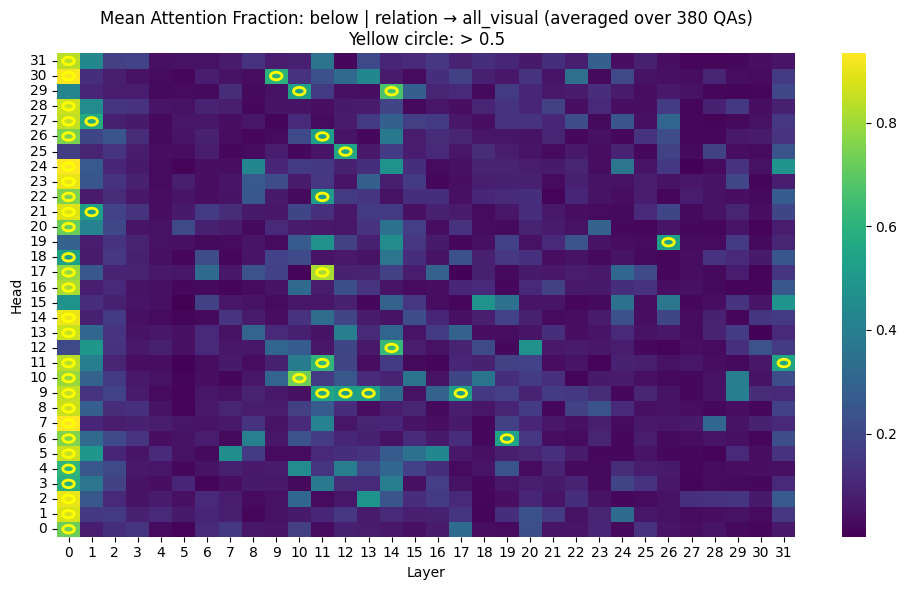

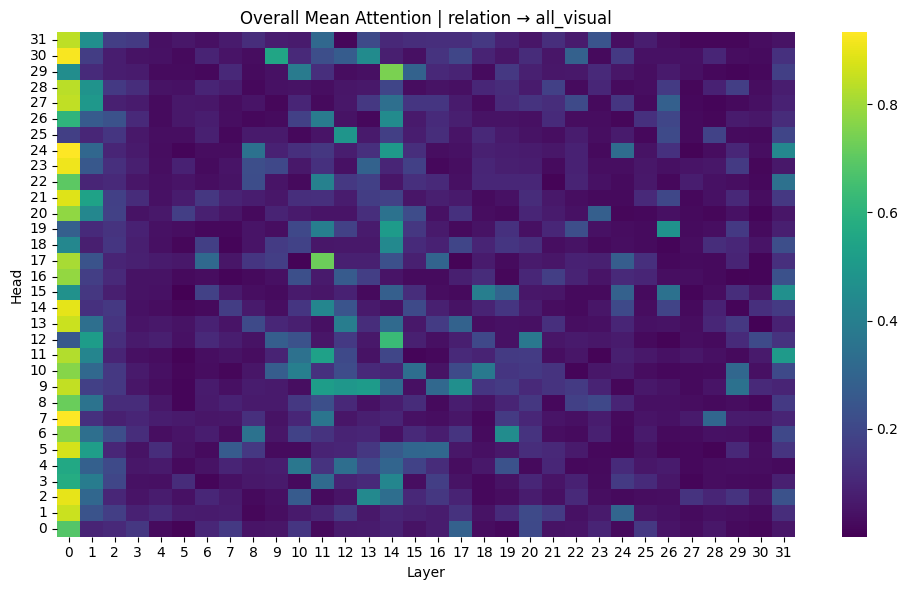

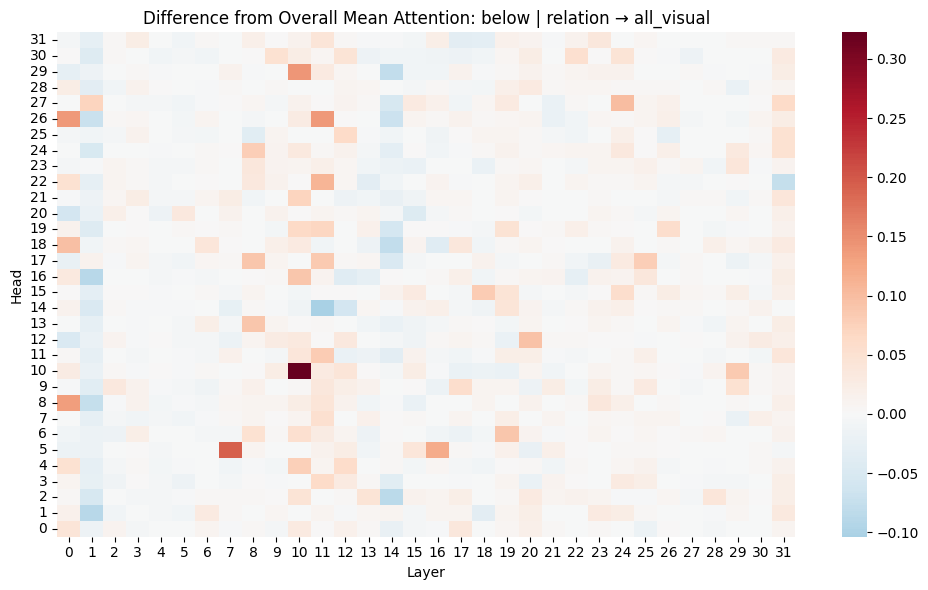

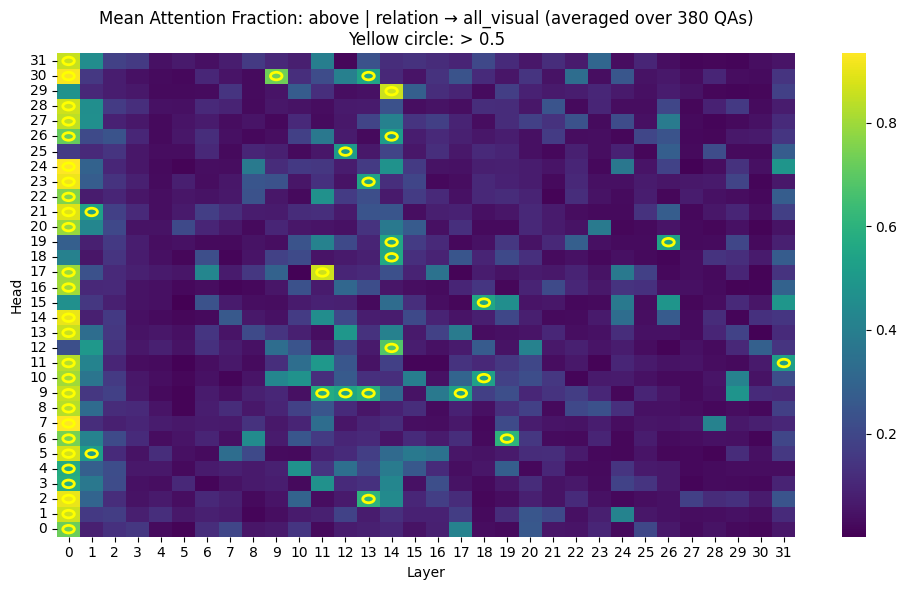

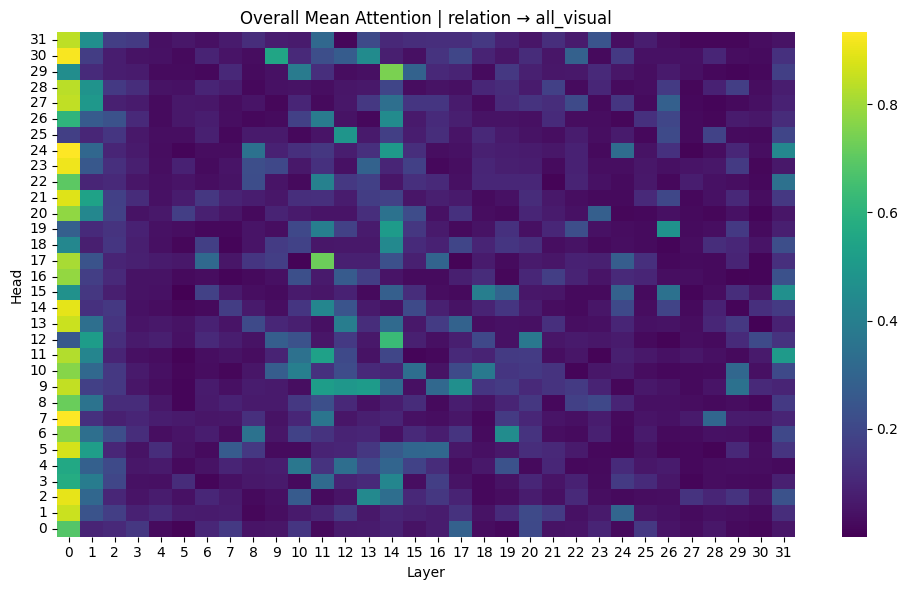

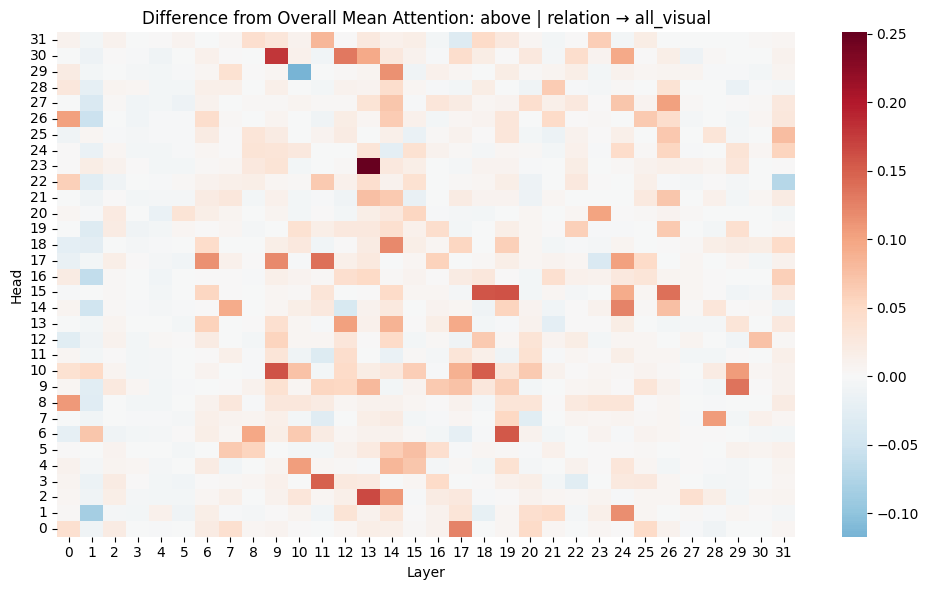

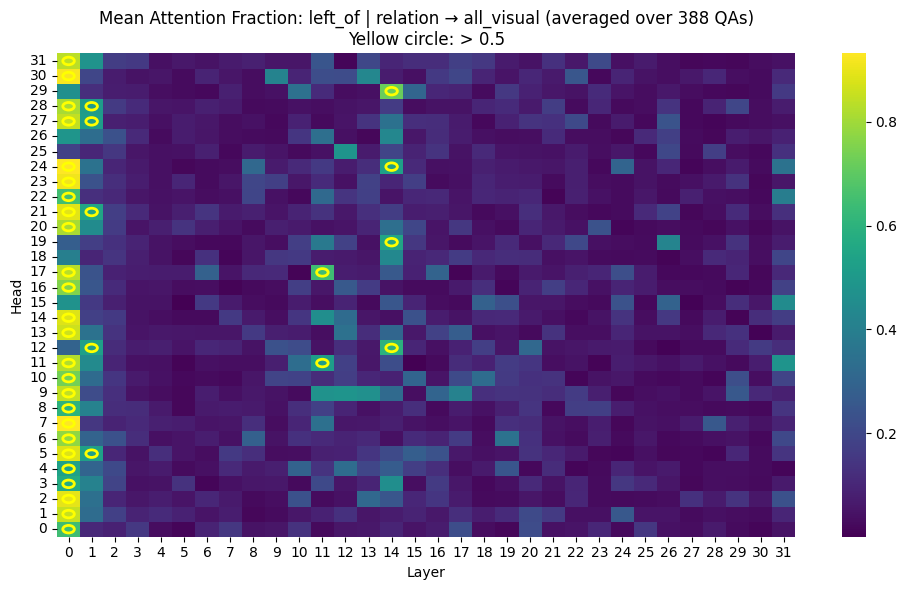

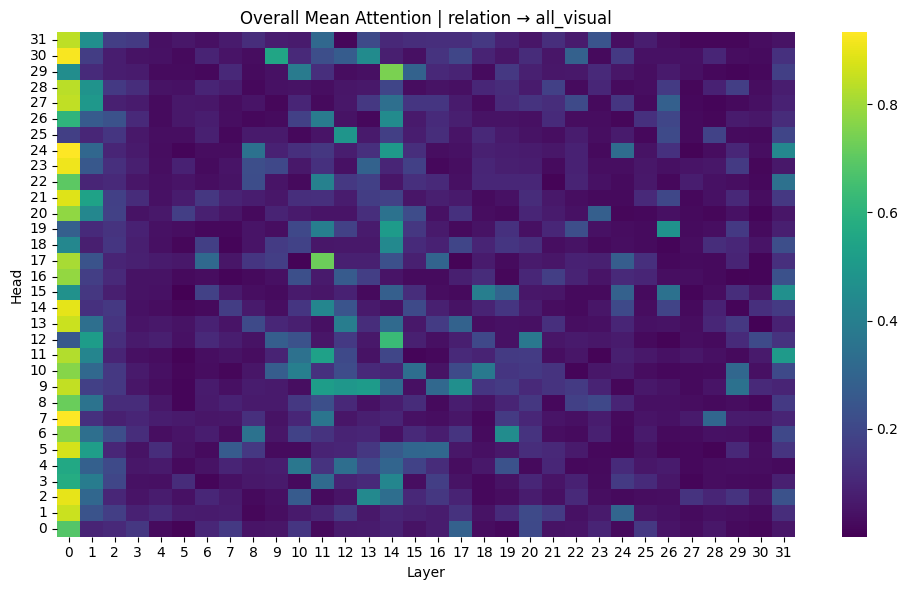

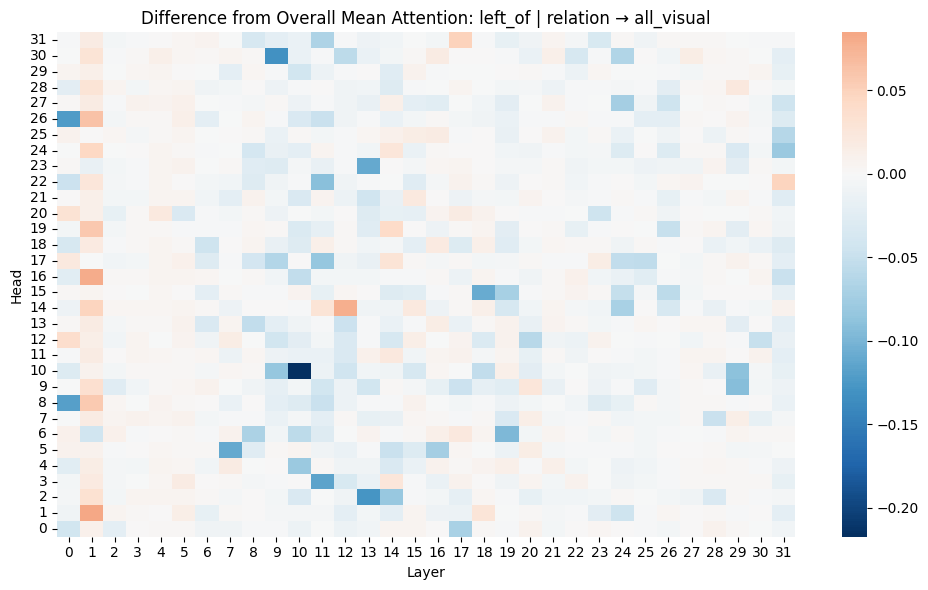

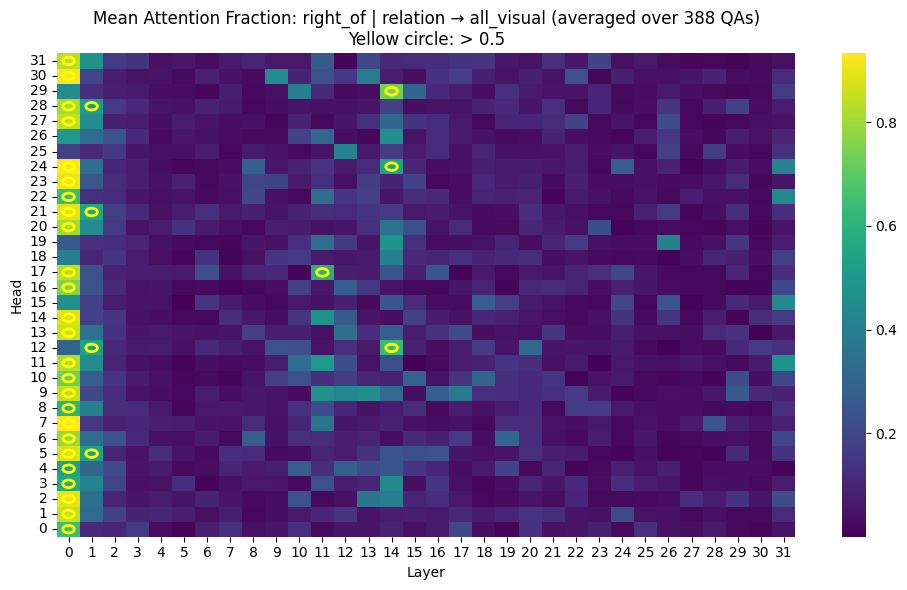

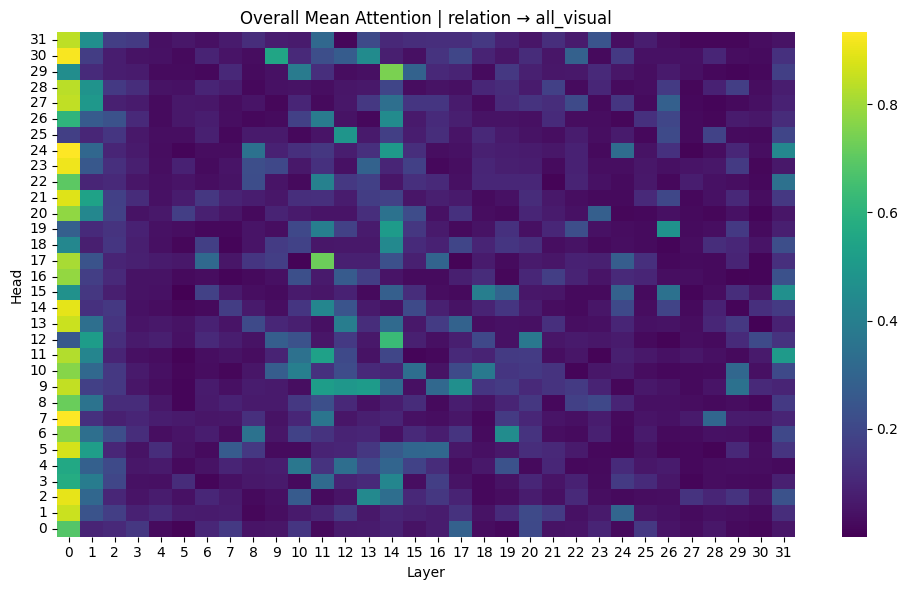

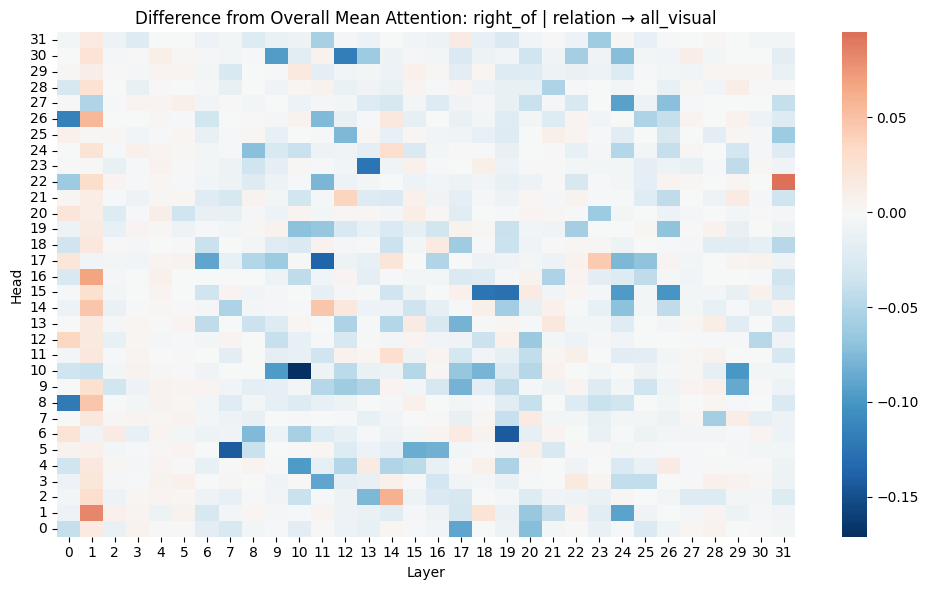

In [ ]:
# Collect all grids for each (relation_type, src, tgt) pair
relation_pair_to_grids = {}

# Specify the group pairs you want to plot entropy for
selected_group_pairs = [
    # ("last", "all_visual"),
    ("relation", "all_visual"),
    # Add more (src, tgt) pairs as needed
]


for result in results:
    relation_type = result["relation_type"]  # Extract relation_type from each result
    attn_metrics = result["attention_metrics"]
    for pair in attn_metrics["group_pairs"]:
        src = pair["source_group"]
        tgt = pair["target_group"]
        if (src, tgt) not in selected_group_pairs:
            continue
        per_layer = pair["per_layer"]
        attn_grid = np.array([layer["per_head_fraction"] for layer in per_layer])  # (layers, heads)
        key = (relation_type, src, tgt)  # Include relation_type in the key
        relation_pair_to_grids.setdefault(key, []).append(attn_grid)

# Compute and plot the mean grid for each (relation_type, src, tgt) combination
# First, compute overall mean across all relations for each (src, tgt)
overall_means_frac = {}
for (relation, src, tgt), grids in relation_pair_to_grids.items():
    if (src, tgt) not in overall_means_frac:
        overall_means_frac[(src, tgt)] = []
    overall_means_frac[(src, tgt)].extend(grids)

for key, all_grids in overall_means_frac.items():
    overall_means_frac[key] = np.mean(all_grids, axis=0)

THRESHOLD = 0.5  # Set your desired threshold here
for (relation, src, tgt), grids in relation_pair_to_grids.items():
    mean_grid = np.mean(grids, axis=0)  # mean over all QAs for this relation and pair
    overall_mean_grid = overall_means_frac[(src, tgt)]
    diff_grid = mean_grid - overall_mean_grid  # Difference from overall mean
    
    # Swap axes: heads on y-axis, layers on x-axis
    mean_grid_swapped = mean_grid.T
    plt.figure(figsize=(10, 6))
    ax = sns.heatmap(mean_grid_swapped, cmap="viridis", annot=False)
    # Mark cells above threshold with a hollow yellow circle
    for y in range(mean_grid_swapped.shape[0]):  # heads
        for x in range(mean_grid_swapped.shape[1]):  # layers
            if mean_grid_swapped[y, x] > THRESHOLD:
                circle = plt.Circle((x + 0.5, y + 0.5), 0.25, color="yellow", fill=False, linewidth=2)
                ax.add_patch(circle)
    plt.title(f"Mean Attention Fraction: {relation} | {src} → {tgt} (averaged over {len(grids)} QAs)\nYellow circle: > {THRESHOLD}")
    plt.xlabel("Layer")
    plt.ylabel("Head")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

    # Plot Overall Mean for reference grid
    overall_mean_grid_swapped = overall_mean_grid.T
    plt.figure(figsize=(10, 6))
    ax = sns.heatmap(overall_mean_grid_swapped, cmap="viridis", annot=False)  # Diverging colormap centered at 0
    plt.title(f"Overall Mean Attention | {src} → {tgt}")
    plt.xlabel("Layer")
    plt.ylabel("Head")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
    
    # Plot difference grid
    diff_grid_swapped = diff_grid.T
    plt.figure(figsize=(10, 6))
    ax = sns.heatmap(diff_grid_swapped, cmap="RdBu_r", annot=False, center=0)  # Diverging colormap centered at 0
    plt.title(f"Difference from Overall Mean Attention: {relation} | {src} → {tgt}")
    plt.xlabel("Layer")
    plt.ylabel("Head")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

# How focussed are the "looking at" behaviours of the relational-phrase and the last tokens? An Attention Analysis

Entropy grid shape: (32, 32), min: 1.9152, max: 6.3469
Entropy grid shape: (32, 32), min: 1.9521, max: 6.3466
Entropy grid shape: (32, 32), min: 2.0201, max: 6.3466
Entropy grid shape: (32, 32), min: 1.9735, max: 6.3469
Entropy grid shape: (32, 32), min: 1.7255, max: 6.3470
Entropy grid shape: (32, 32), min: 1.7662, max: 6.3466
Entropy grid shape: (32, 32), min: 1.6392, max: 6.3467
Entropy grid shape: (32, 32), min: 1.7777, max: 6.3471
Entropy grid shape: (32, 32), min: 2.0071, max: 6.3473
Entropy grid shape: (32, 32), min: 2.0531, max: 6.3469
Entropy grid shape: (32, 32), min: 2.0379, max: 6.3469
Entropy grid shape: (32, 32), min: 2.0078, max: 6.3473
Entropy grid shape: (32, 32), min: 1.6865, max: 6.3479
Entropy grid shape: (32, 32), min: 1.6659, max: 6.3475
Entropy grid shape: (32, 32), min: 1.5981, max: 6.3475
Entropy grid shape: (32, 32), min: 1.6843, max: 6.3479
Entropy grid shape: (32, 32), min: 2.1397, max: 6.3465
Entropy grid shape: (32, 32), min: 2.1638, max: 6.3466
Entropy gr

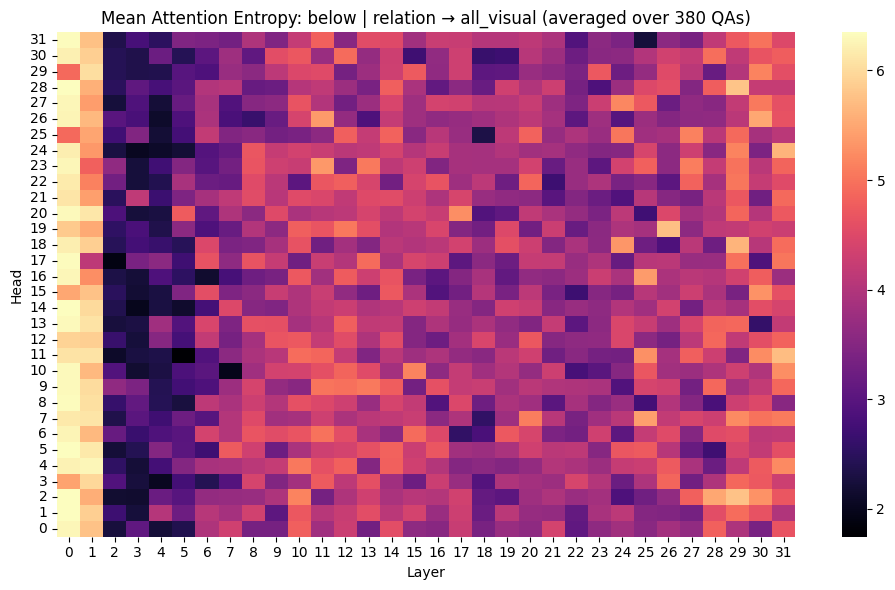

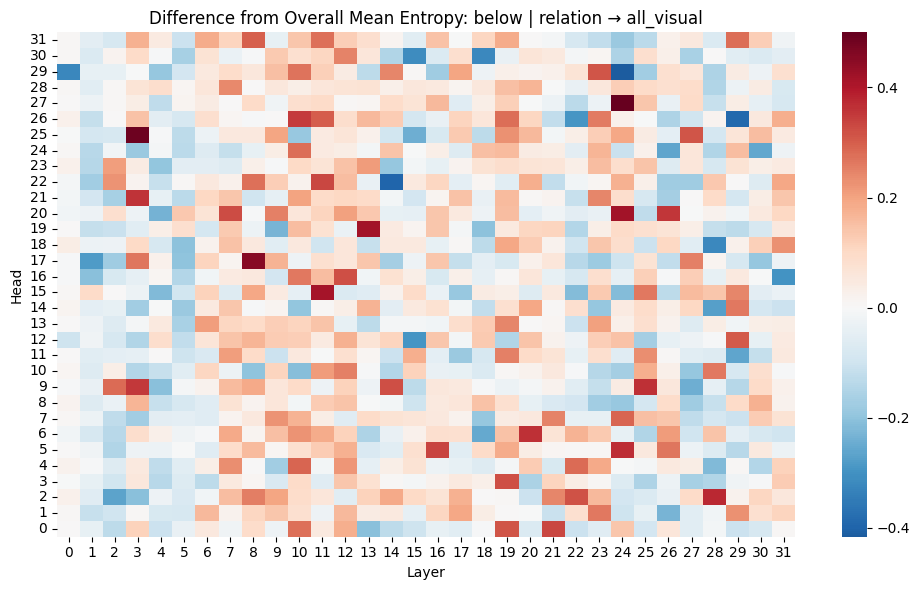

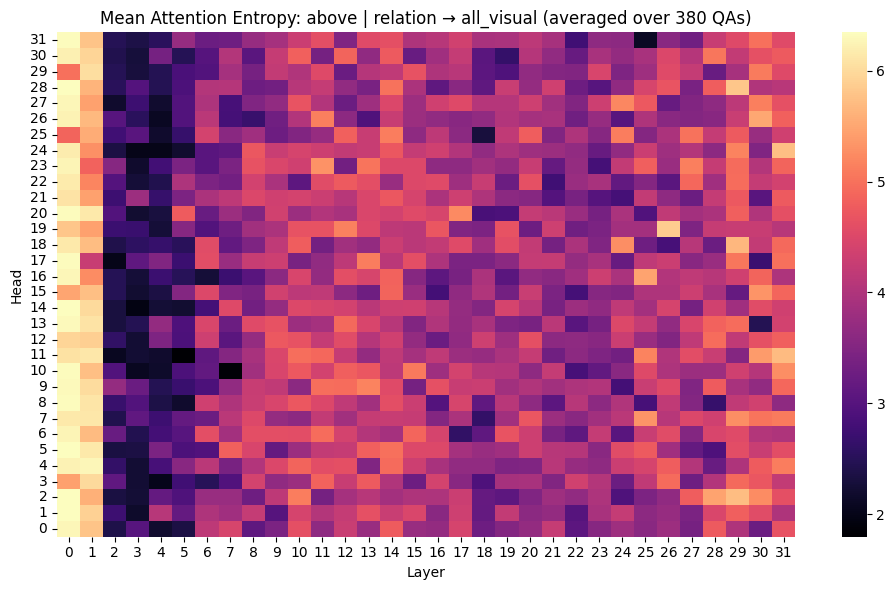

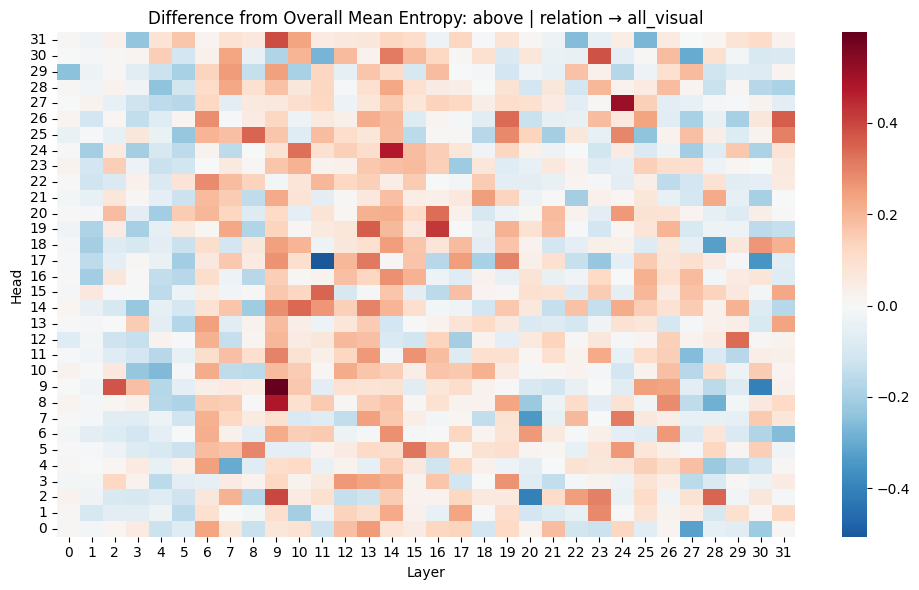

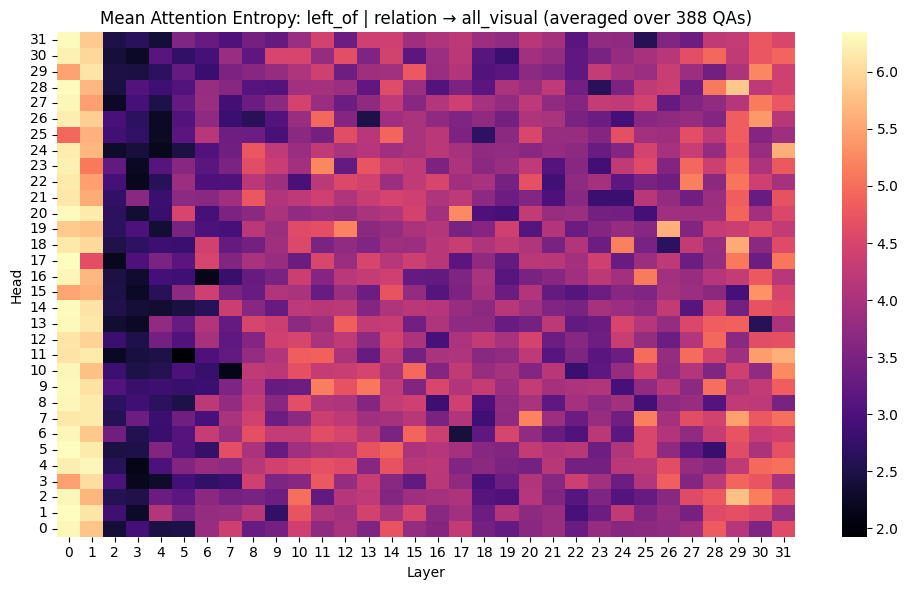

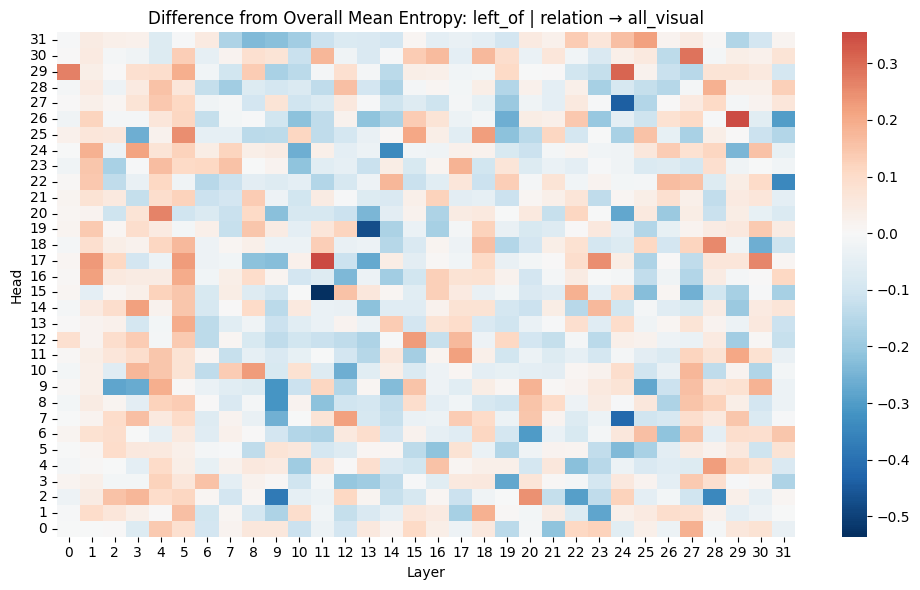

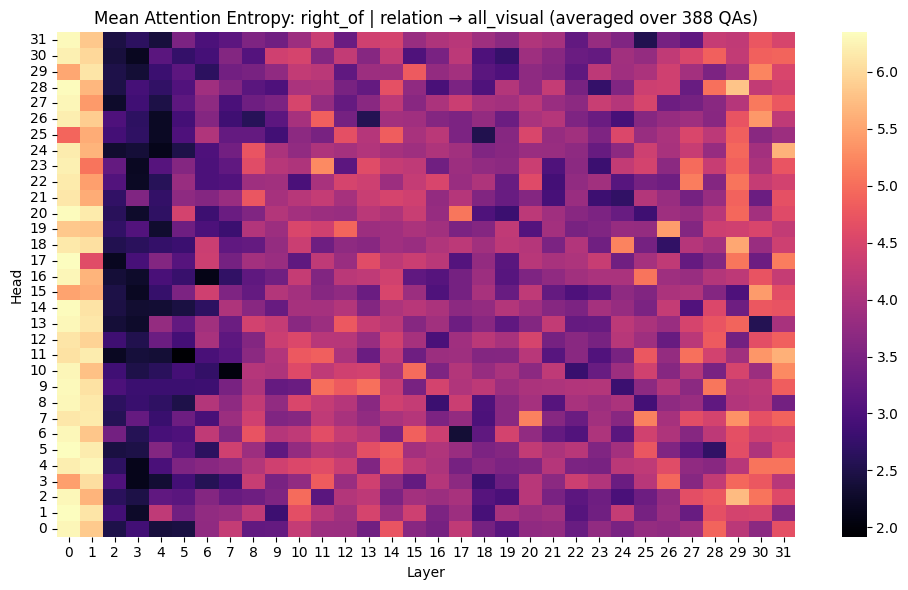

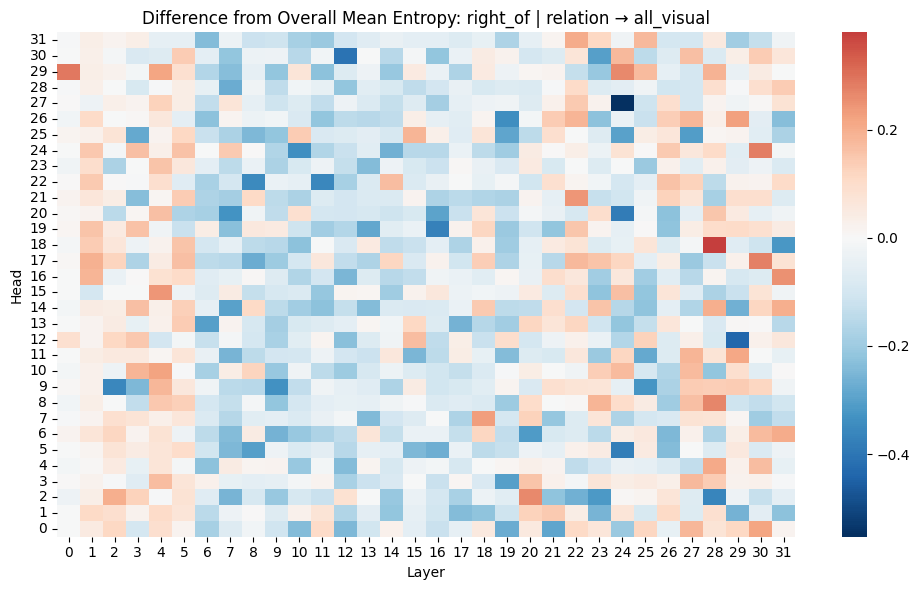

In [ ]:
# Collect all grids for each (src, tgt) pair (entropy version, filtered group pairs)

# Specify the group pairs you want to plot entropy for
selected_group_pairs = [
    # ("last", "all_visual"),
    ("relation", "all_visual"),
    # Add more (src, tgt) pairs as needed
]

relation_pair_to_entropy_grids = {}

for result in results:
    attn_metrics = result["attention_metrics"]
    relation_type = result["relation_type"]
    for pair in attn_metrics["group_pairs"]:
        src = pair["source_group"]
        tgt = pair["target_group"]
        if (src, tgt) not in selected_group_pairs:
            continue
        per_layer = pair["per_layer"]
        # Use entropy instead of fraction
        entropy_grid = np.array([layer["per_head_entropy"] for layer in per_layer])  # (layers, heads)
        print(f"Entropy grid shape: {entropy_grid.shape}, min: {entropy_grid.min():.4f}, max: {entropy_grid.max():.4f}")
        key = (relation_type, src, tgt)  # Include relation_type in the key
        relation_pair_to_entropy_grids.setdefault(key, []).append(entropy_grid)

# Compute and plot the mean entropy grid for each selected pair
# First, compute overall mean across all relations for each (src, tgt)
overall_means = {}
for (relation, src, tgt), grids in relation_pair_to_entropy_grids.items():
    if (src, tgt) not in overall_means:
        overall_means[(src, tgt)] = []
    overall_means[(src, tgt)].extend(grids)

for key, all_grids in overall_means.items():
    overall_means[key] = np.mean(all_grids, axis=0)

for (relation, src, tgt), grids in relation_pair_to_entropy_grids.items():
    mean_grid = np.mean(grids, axis=0)  # mean over all QAs
    overall_mean_grid = overall_means[(src, tgt)]
    diff_grid = mean_grid - overall_mean_grid  # Difference from overall mean
    
    # Plot mean grid
    mean_grid_swapped = mean_grid.T
    plt.figure(figsize=(10, 6))
    ax = sns.heatmap(mean_grid_swapped, cmap="magma", annot=False)
    plt.title(f"Mean Attention Entropy: {relation} | {src} → {tgt} (averaged over {len(grids)} QAs)")
    plt.xlabel("Layer")
    plt.ylabel("Head")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
    
    # Plot difference grid
    diff_grid_swapped = diff_grid.T
    plt.figure(figsize=(10, 6))
    ax = sns.heatmap(diff_grid_swapped, cmap="RdBu_r", annot=False, center=0)  # Diverging colormap centered at 0
    plt.title(f"Difference from Overall Mean Entropy: {relation} | {src} → {tgt}")
    plt.xlabel("Layer")
    plt.ylabel("Head")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

Here, I plot violin curves to see distribution of entropy for a specific head in a layer, by relation type. This will be useful in seeing if this head behaves differently for different relation types. Candidate heads are taken from those that have different attention fraction to the mean. 

candidates = [(9, 8), (9, 9), (10, 10), (11, 17), (13, 19), (14, 24), (13, 23), (31, 22), (14, 2)] 

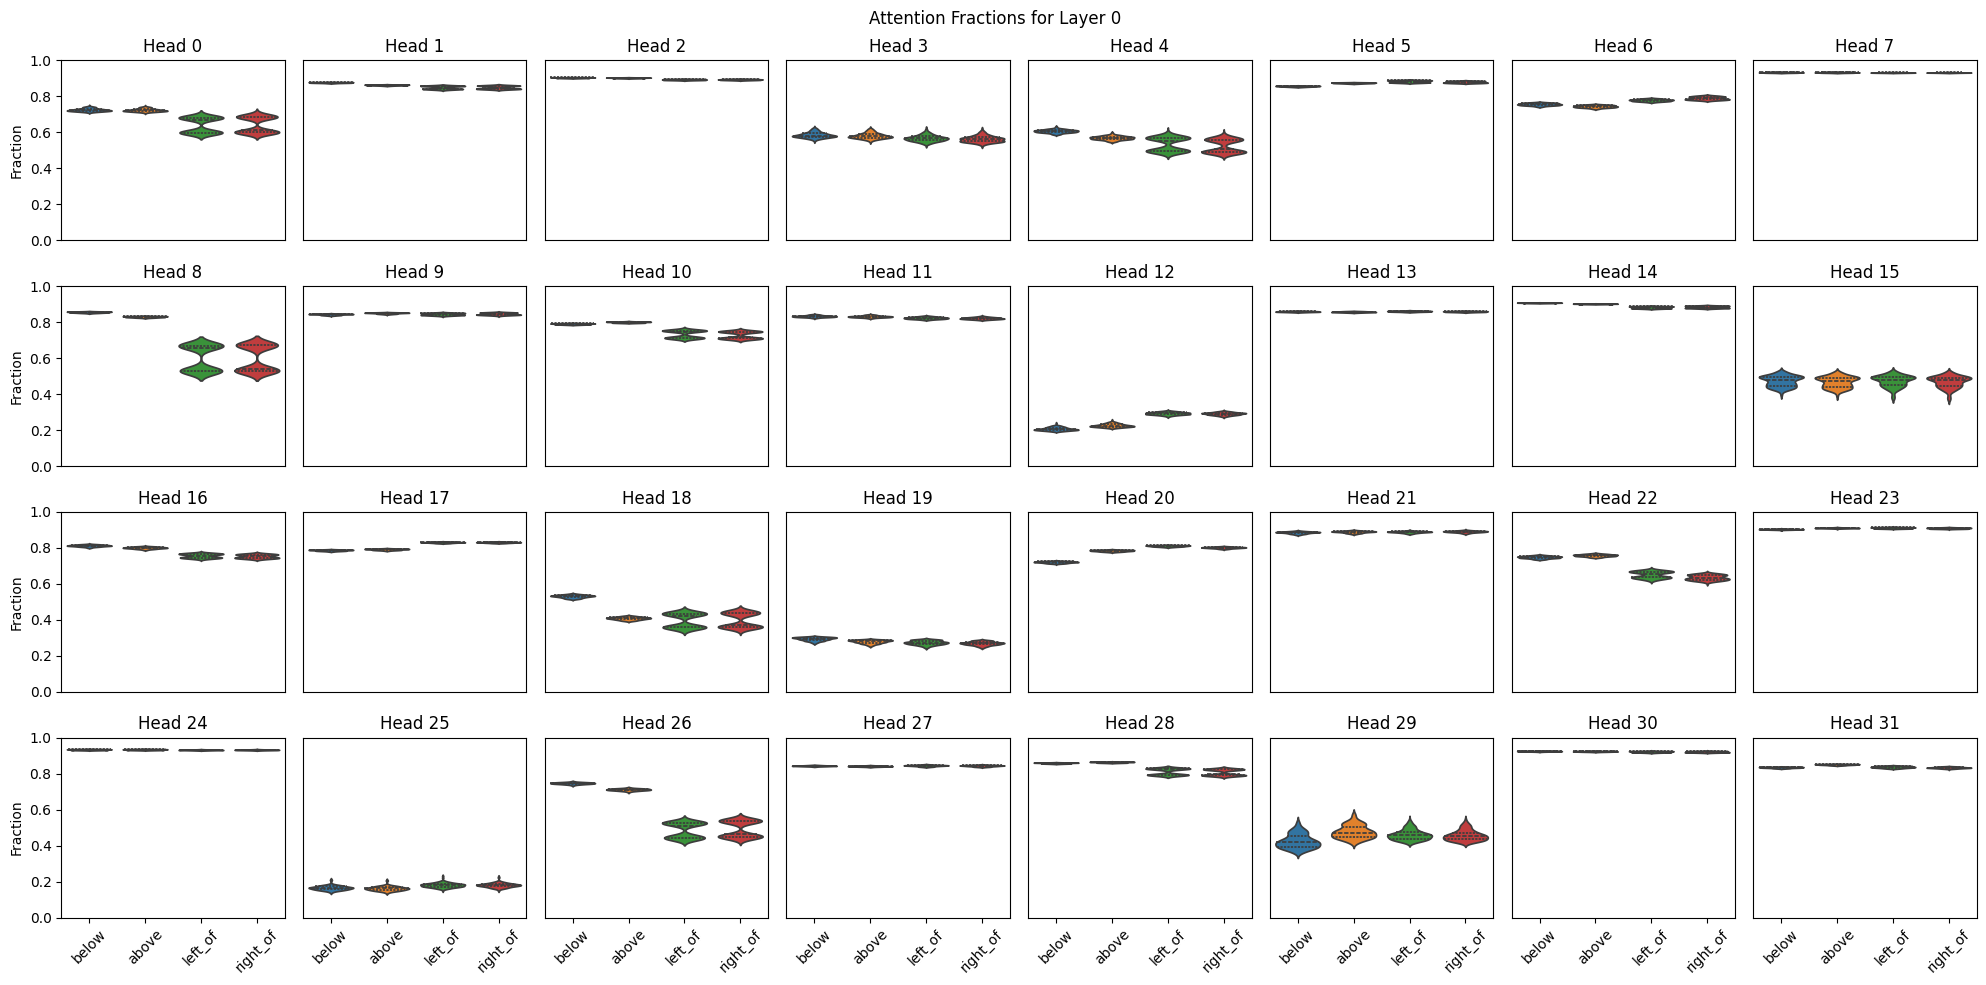

KeyboardInterrupt: 

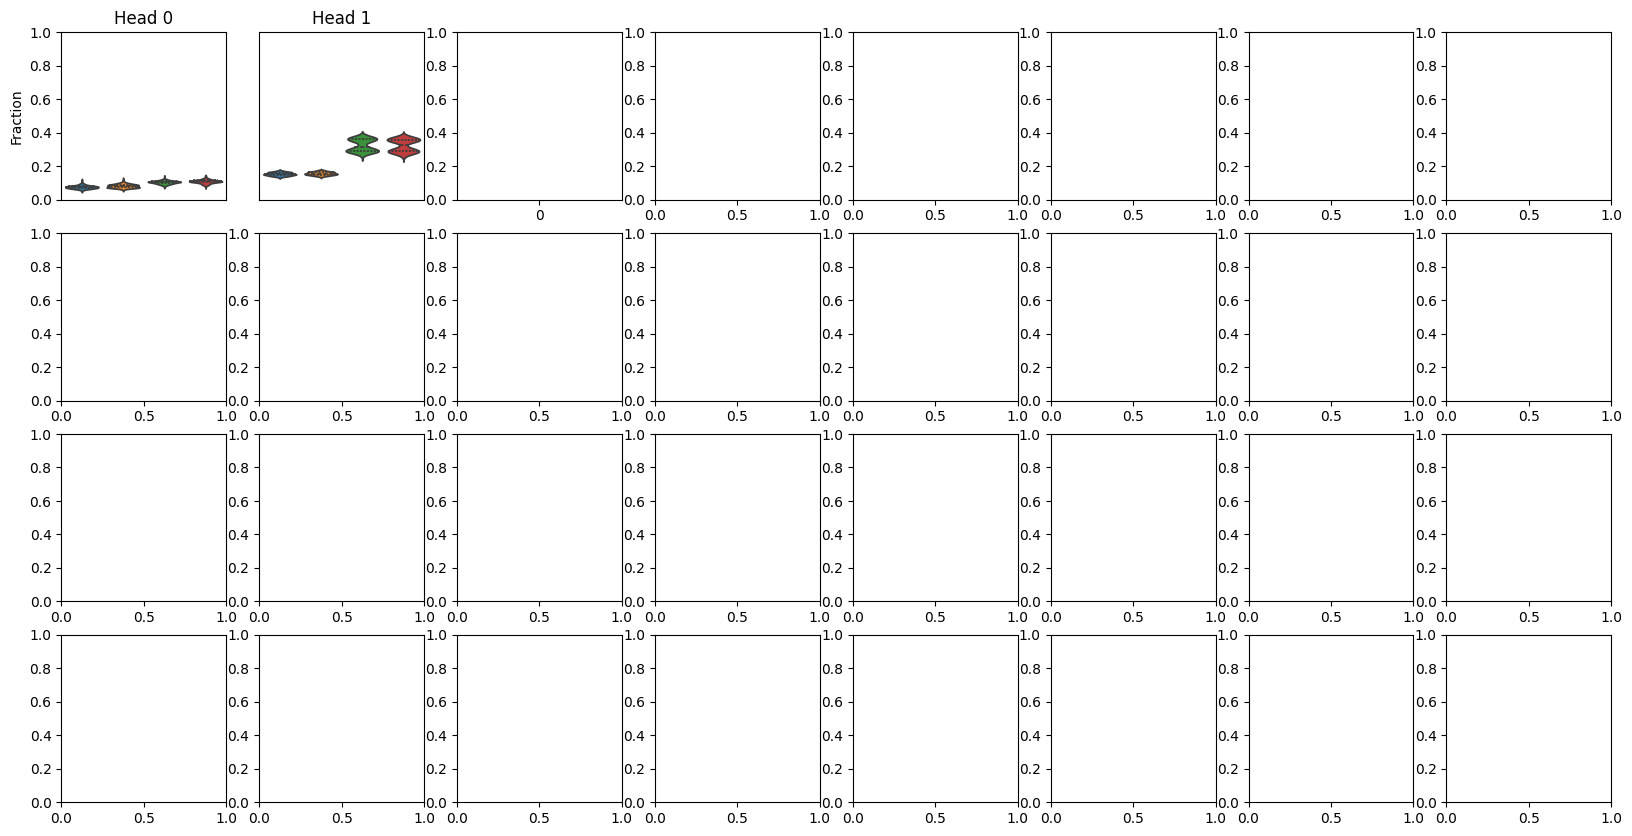

In [ ]:
# Specify the layers to plot
layers = range(0, 32)  # Change this to the desired layers

selected_group_pairs = [("relation", "all_visual")]

for selected_layer in layers:
    # Collect fractions for each head in the selected layer per relation type
    fractions_per_head_relation = {}

    for result in results:
        relation_type = result["relation_type"]
        attn_metrics = result["attention_metrics"]
        for pair in attn_metrics["group_pairs"]:
            src = pair["source_group"]
            tgt = pair["target_group"]
            if (src, tgt) not in selected_group_pairs:
                continue
            per_layer = pair["per_layer"]
            layer_data = per_layer[selected_layer]
            per_head_fraction = layer_data["per_head_fraction"]
            for head_idx, frac in enumerate(per_head_fraction):
                if head_idx not in fractions_per_head_relation:
                    fractions_per_head_relation[head_idx] = {}
                if relation_type not in fractions_per_head_relation[head_idx]:
                    fractions_per_head_relation[head_idx][relation_type] = []
                fractions_per_head_relation[head_idx][relation_type].append(frac)

    # Now plot violin plots for each head in the selected layer, with violins for each relation type
    num_heads = 32
    fig, axes = plt.subplots(4, 8, figsize=(20, 10))  # 4 rows, 8 columns for 32 heads
    axes = axes.flatten()
    
    for head in range(num_heads):
        ax = axes[head]

        # ---- FIX Y AXIS RANGE ----
        ax.set_ylim(0, 1)
        row = head // 8
        col = head % 8

        if head in fractions_per_head_relation:
            relation_fractions = fractions_per_head_relation[head]
            data = list(relation_fractions.values())
            labels = list(relation_fractions.keys())
            sns.violinplot(data=data, ax=ax, inner="quartile")

            # ---- X AXIS: only bottom row ----
            if row == 3:
                ax.set_xticks(range(len(labels)))
                ax.set_xticklabels(labels, rotation=45)
            else:
                ax.set_xticks([])
                ax.set_xticklabels([])

            # ---- Y AXIS: only first column ----
            if col == 0:
                ax.set_ylabel("Fraction")
            else:
                ax.set_yticks([])
                ax.set_ylabel("")

            ax.set_title(f'Head {head}')
            ax.set_xlabel('')
        else:
            ax.text(0.5, 0.5, 'No data', transform=ax.transAxes, ha='center')
            ax.set_title(f'Head {head}')
    fig.suptitle(f'Attention Fractions for Layer {selected_layer}')
    plt.tight_layout()
    plt.savefig(f'../results_llava-hf/llava-1.5-7b-hf/attention_fraction_analysis/layer{selected_layer}_fractions.png')
    plt.show()

In [ ]:
# Specify the layers to plot
layers = range(0, 32)  # Change this to the desired layers

selected_group_pairs = [("relation", "all_visual")]

for selected_layer in layers:
    # Collect fractions for each head in the selected layer per relation type
    fractions_per_head_relation = {}

    for result in results:
        relation_type = result["relation_type"]
        attn_metrics = result["attention_metrics"]
        for pair in attn_metrics["group_pairs"]:
            src = pair["source_group"]
            tgt = pair["target_group"]
            if (src, tgt) not in selected_group_pairs:
                continue
            per_layer = pair["per_layer"]
            layer_data = per_layer[selected_layer]
            per_head_fraction = layer_data["per_head_fraction"]
            for head_idx, frac in enumerate(per_head_fraction):
                if head_idx not in fractions_per_head_relation:
                    fractions_per_head_relation[head_idx] = {}
                if relation_type not in fractions_per_head_relation[head_idx]:
                    fractions_per_head_relation[head_idx][relation_type] = []
                fractions_per_head_relation[head_idx][relation_type].append(frac)

    # Compute overall mean per head
    overall_mean_per_head = {}
    for head, relations in fractions_per_head_relation.items():
        all_values = []
        for rel, vals in relations.items():
            all_values.extend(vals)
        overall_mean_per_head[head] = np.mean(all_values)

    # Compute differences from overall mean
    diff_per_head_relation = {}
    for head, relations in fractions_per_head_relation.items():
        diff_per_head_relation[head] = {}
        for rel, vals in relations.items():
            diff = [v - overall_mean_per_head[head] for v in vals]
            diff_per_head_relation[head][rel] = diff

    # Now plot violin plots for each head in the selected layer, with violins for each relation type (differences)
    num_heads = 32
    fig, axes = plt.subplots(4, 8, figsize=(20, 10))  # 4 rows, 8 columns for 32 heads
    axes = axes.flatten()
    
    for head in range(num_heads):
        ax = axes[head]

        # ---- FIX Y AXIS RANGE ----
        # For differences, center around 0
        ax.set_ylim(-0.5, 0.5)
        row = head // 8
        col = head % 8

        if head in diff_per_head_relation:
            relation_diffs = diff_per_head_relation[head]
            data = list(relation_diffs.values())
            labels = list(relation_diffs.keys())
            sns.violinplot(data=data, ax=ax, inner="quartile")

            # ---- X AXIS: only bottom row ----
            if row == 3:
                ax.set_xticks(range(len(labels)))
                ax.set_xticklabels(labels, rotation=45)
            else:
                ax.set_xticks([])
                ax.set_xticklabels([])

            # ---- Y AXIS: only first column ----
            if col == 0:
                ax.set_ylabel("Difference in Fraction")
            else:
                ax.set_yticks([])
                ax.set_ylabel("")

            ax.set_title(f'Head {head}')
            ax.set_xlabel('')
        else:
            ax.text(0.5, 0.5, 'No data', transform=ax.transAxes, ha='center')
            ax.set_title(f'Head {head}')
    fig.suptitle(f'Difference from Overall Mean Attention Fraction for Layer {selected_layer}')
    plt.tight_layout()
    plt.savefig(f'../results_llava-hf/llava-1.5-7b-hf/attention_fraction_analysis/layer{selected_layer}_fraction_diffs.png')
    plt.show()

NameError: name 'results' is not defined

This looks at the same as above, but for attention entropy and not attention fraction.

In [ ]:

# Specify the layers to plot
layers = range(0,32)  # Change this to the desired layers

selected_group_pairs = [("relation", "all_visual")]

for selected_layer in layers:
    # Collect entropies for each head in the selected layer per relation type
    entropy_per_head_relation = {}

    for result in results:
        relation_type = result["relation_type"]
        attn_metrics = result["attention_metrics"]
        for pair in attn_metrics["group_pairs"]:
            src = pair["source_group"]
            tgt = pair["target_group"]
            if (src, tgt) not in selected_group_pairs:
                continue
            per_layer = pair["per_layer"]
            layer_data = per_layer[selected_layer]
            per_head_entropy = layer_data["per_head_entropy"]
            for head_idx, entropy in enumerate(per_head_entropy):
                if head_idx not in entropy_per_head_relation:
                    entropy_per_head_relation[head_idx] = {}
                if relation_type not in entropy_per_head_relation[head_idx]:
                    entropy_per_head_relation[head_idx][relation_type] = []
                entropy_per_head_relation[head_idx][relation_type].append(entropy)

    # Now plot violin plots for each head in the selected layer, with violins for each relation type
    num_heads = 32
    fig, axes = plt.subplots(4, 8, figsize=(20, 10))  # 4 rows, 8 columns for 32 heads
    axes = axes.flatten()
    for head in range(num_heads):
        ax = axes[head]

        ax.set_ylim(2, 7)
        row = head // 8
        col = head % 8
        if head in entropy_per_head_relation:
            relation_entropy = entropy_per_head_relation[head]
            data = list(relation_entropy.values())
            labels = list(relation_entropy.keys())
            sns.violinplot(data=data, ax=ax, inner="quartile")

            # ---- X AXIS: only bottom row ----
            if row == 3:
                ax.set_xticks(range(len(labels)))
                ax.set_xticklabels(labels, rotation=45)
            else:
                ax.set_xticks([])
                ax.set_xticklabels([])

            # ---- Y AXIS: only first column ----
            if col == 0:
                ax.set_ylabel("Entropy")
            else:
                ax.set_yticks([])
                ax.set_ylabel("")

            ax.set_title(f'Head {head}')
            ax.set_xlabel('')
        else:
            ax.text(0.5, 0.5, 'No data', transform=ax.transAxes, ha='center')
            ax.set_title(f'Head {head}')
    fig.suptitle(f'Attention Entropy for Layer {selected_layer}')
    plt.tight_layout()
    plt.savefig(f'../results_llava-hf/llava-1.5-7b-hf/attention_entropy_analysis/layer{selected_layer}_entropy.png')
    plt.show()

# What layer's have significant attention to image tokens?

In [ ]:
# Compute the per-layer mean_fraction for (last, all_visual) averaged across all QAs
all_per_layer_fractions = []

for result in results:
    # Find the group pair with source_group == 'last' and target_group == 'all_visual'
    pair = next((p for p in result['attention_metrics']['group_pairs']
                 if p['source_group'] == 'last' and p['target_group'] == 'all_visual'), None)
    if pair is not None:
        # Collect the mean_fraction for each layer
        per_layer = pair['per_layer']
        fractions = [layer['mean_fraction'] for layer in per_layer]
        all_per_layer_fractions.append(fractions)

# Convert to numpy array for averaging (shape: num_qas, num_layers)
all_per_layer_fractions = np.array(all_per_layer_fractions)
mean_per_layer_fraction = np.mean(all_per_layer_fractions, axis=0)
print("Mean per-layer fraction (last → all_visual) across all QAs:")
print(mean_per_layer_fraction)

# Print layers with fraction above threshold
THRESHOLD = 0.2  # Set your threshold here
print(f"Layers with mean fraction > {THRESHOLD}:")
for i, frac in enumerate(mean_per_layer_fraction):
    if frac > THRESHOLD:
        print(f"Layer {i}: {frac:.3f}")

# Visualise the directionality of attention (CoM)

This analysis answers questions like: do certain heads look at a certain direction relative to the object in question? For example, if the question is about "left", does it look to the left of the object?

In [6]:
import json

# Load all results from the new JSONL (line-based) file
results_com = []
# TODO: Change it to the latest dataset
with open("../results_llava-hf/llava-1.5-7b-hf/attention_results_all_levels.jsonl", "r") as f:
    for line in f:
        if line.strip():
            results_com.append(json.loads(line))
print(f"Number of inferences: {len(results_com)}")

Number of inferences: 1536



Heads/Layers with significant deviation from mean (normalized):
Relation:   right_of | Layer: 18 | Head: 17 | ΔCoM distance: 0.013
Relation:      above | Layer: 18 | Head: 17 | ΔCoM distance: 0.013
Relation:      below | Layer: 18 | Head: 17 | ΔCoM distance: 0.013
Relation:    left_of | Layer: 18 | Head: 17 | ΔCoM distance: 0.013
Relation:   right_of | Layer: 15 | Head: 11 | ΔCoM distance: 0.013
Relation:   right_of | Layer: 18 | Head:  4 | ΔCoM distance: 0.013
Relation:      below | Layer: 15 | Head: 11 | ΔCoM distance: 0.013
Relation:      above | Layer: 15 | Head: 11 | ΔCoM distance: 0.012
Relation:    left_of | Layer: 15 | Head: 11 | ΔCoM distance: 0.012
Relation:      above | Layer: 18 | Head:  4 | ΔCoM distance: 0.012
Relation:   right_of | Layer: 14 | Head: 29 | ΔCoM distance: 0.012
Relation:   right_of | Layer: 19 | Head: 28 | ΔCoM distance: 0.012
Relation:   right_of | Layer: 14 | Head: 24 | ΔCoM distance: 0.012
Relation:      below | Layer: 18 | Head:  4 | ΔCoM distance: 0.0

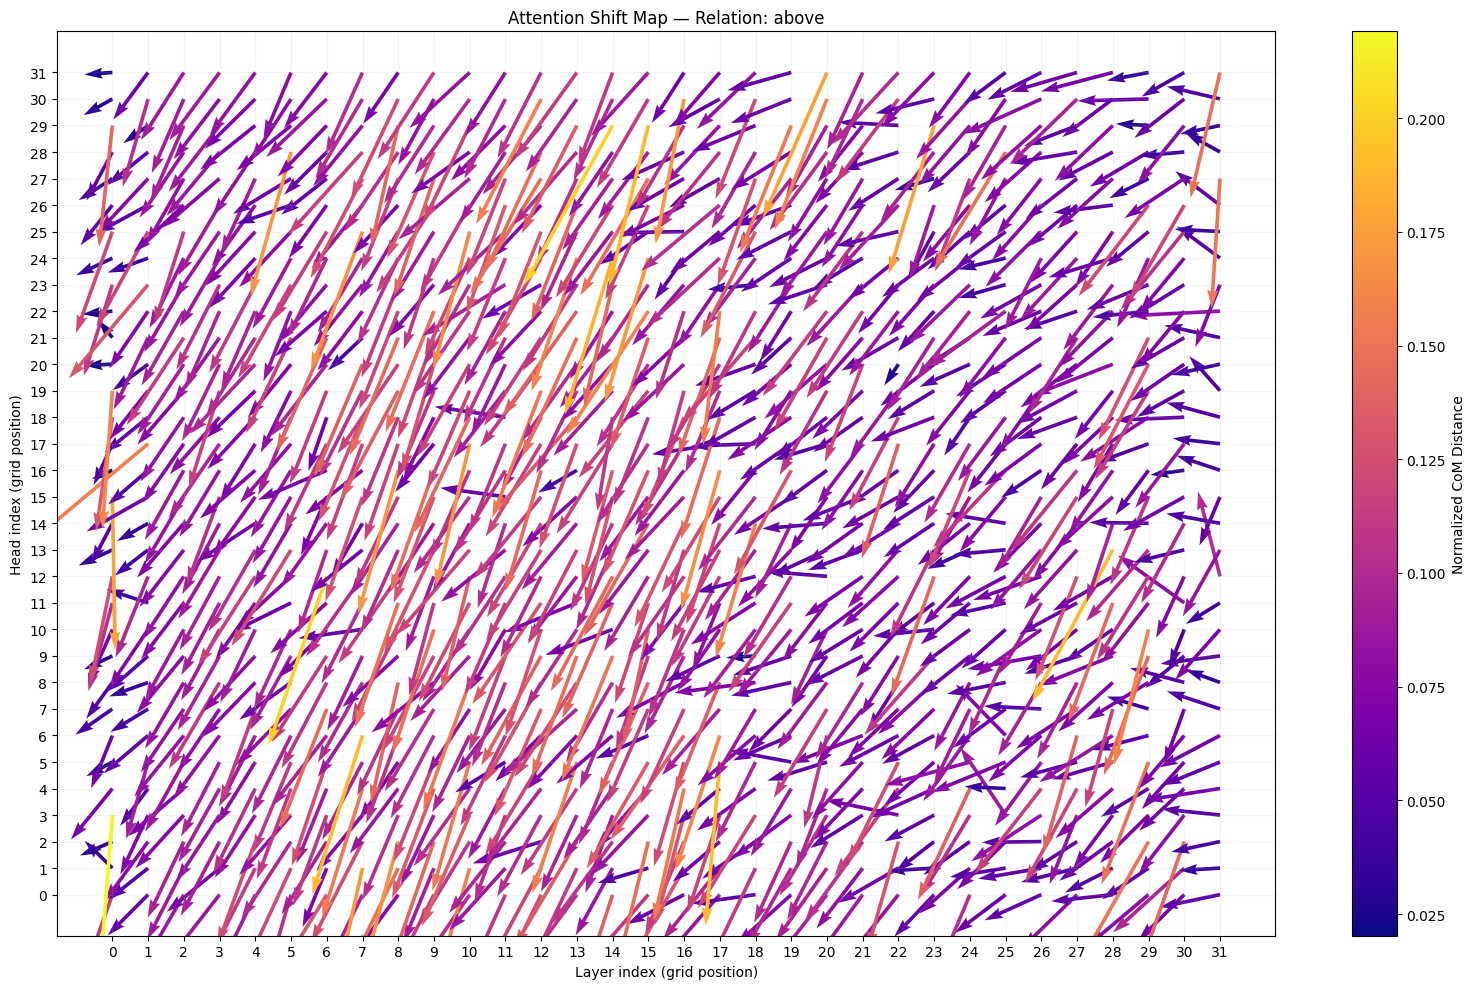

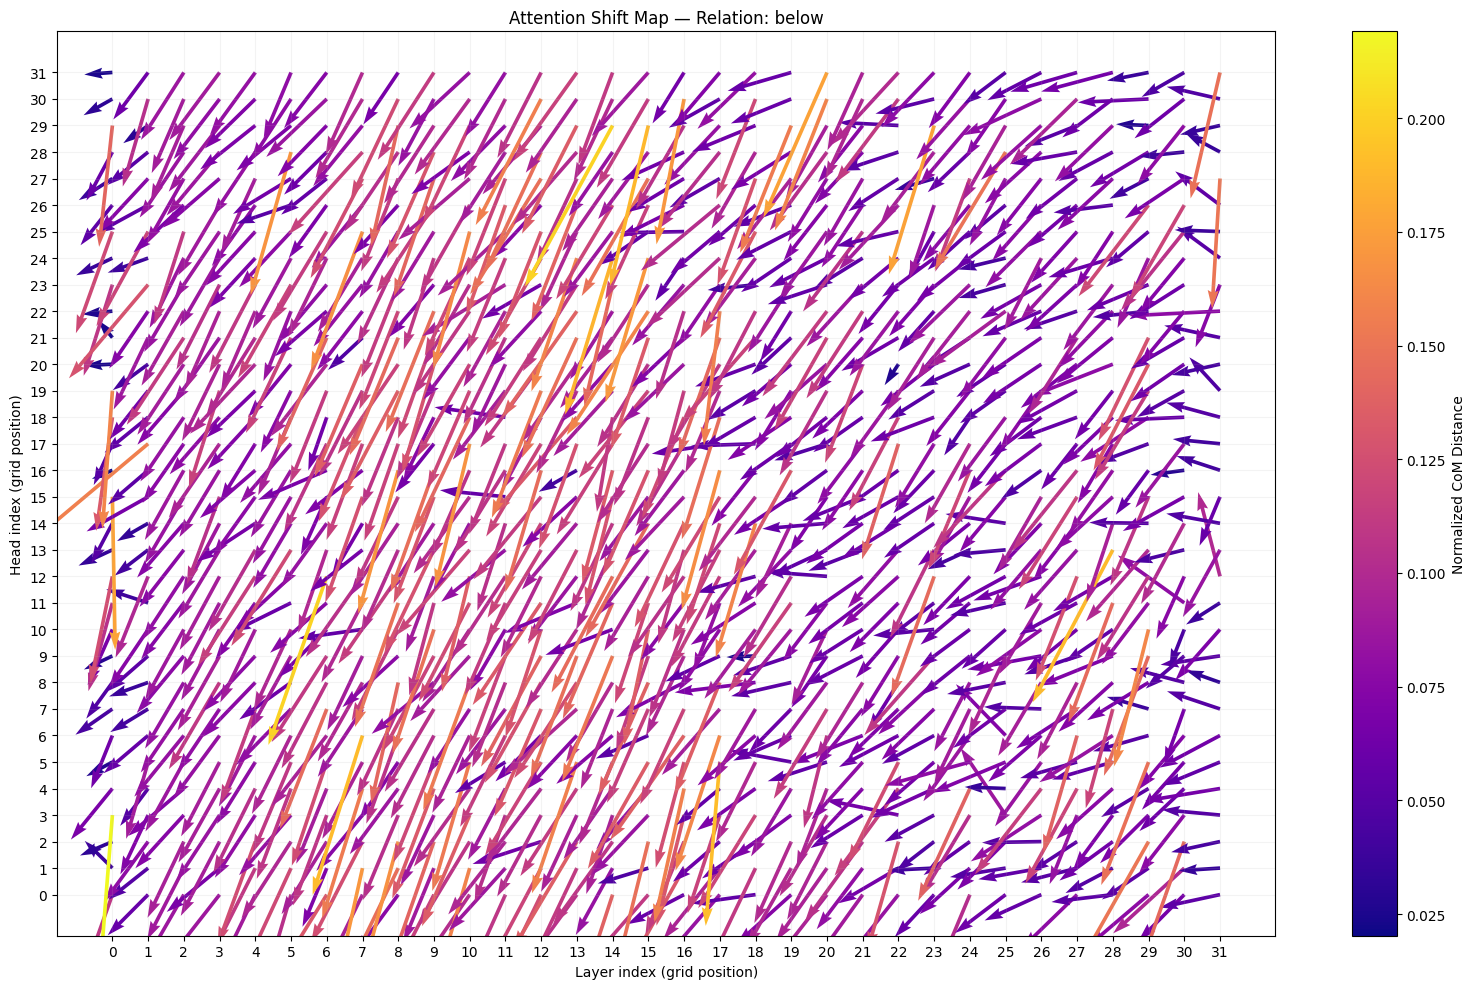

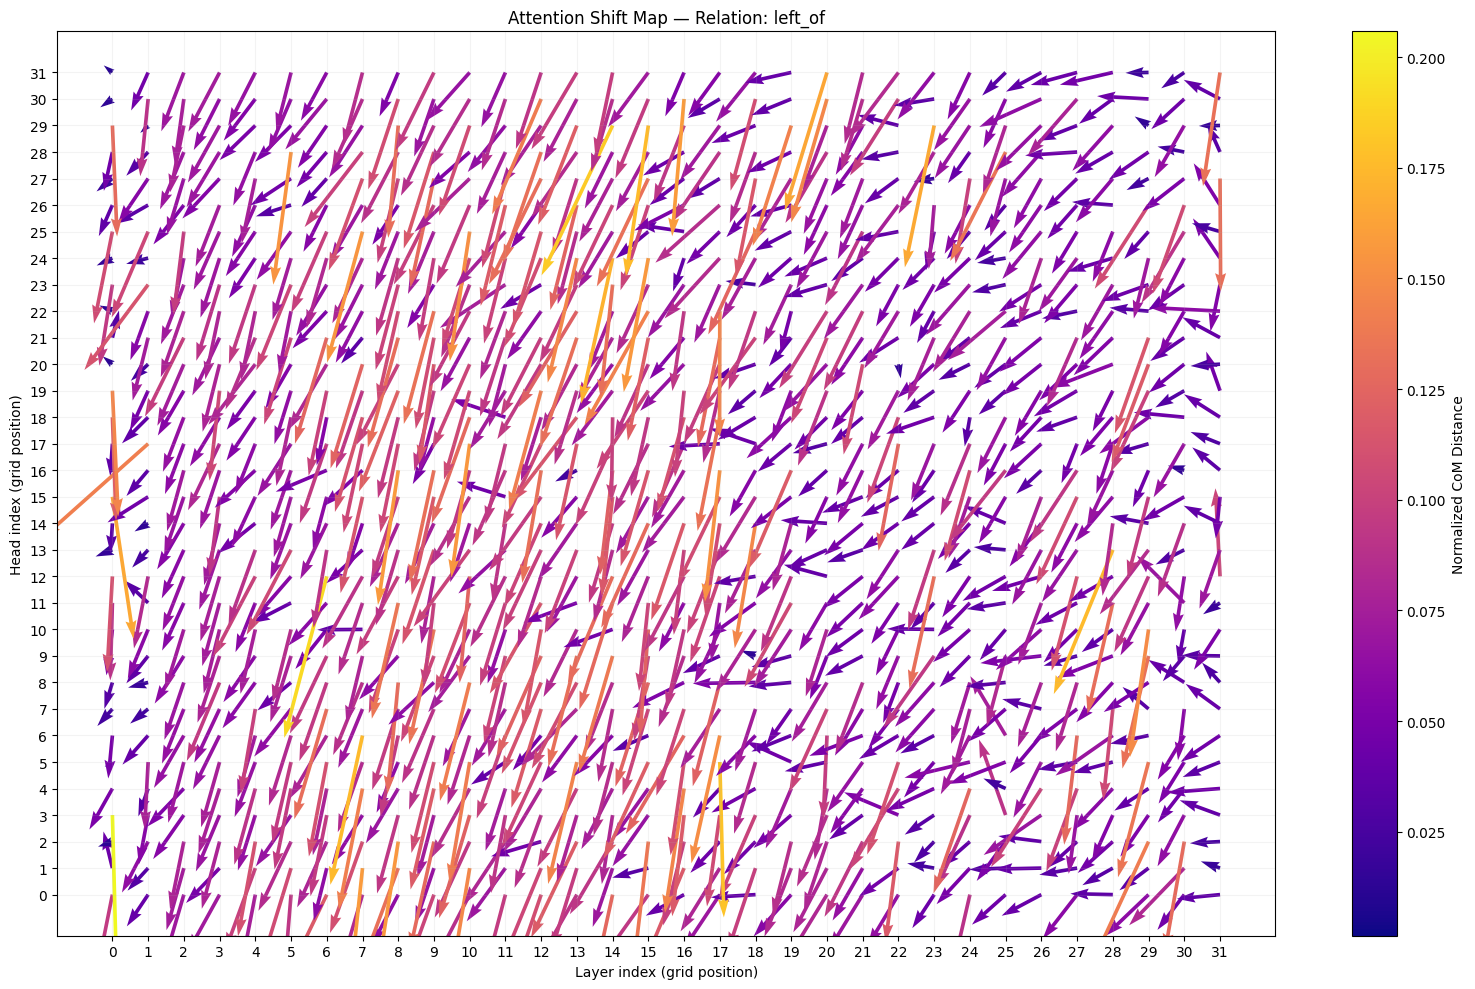

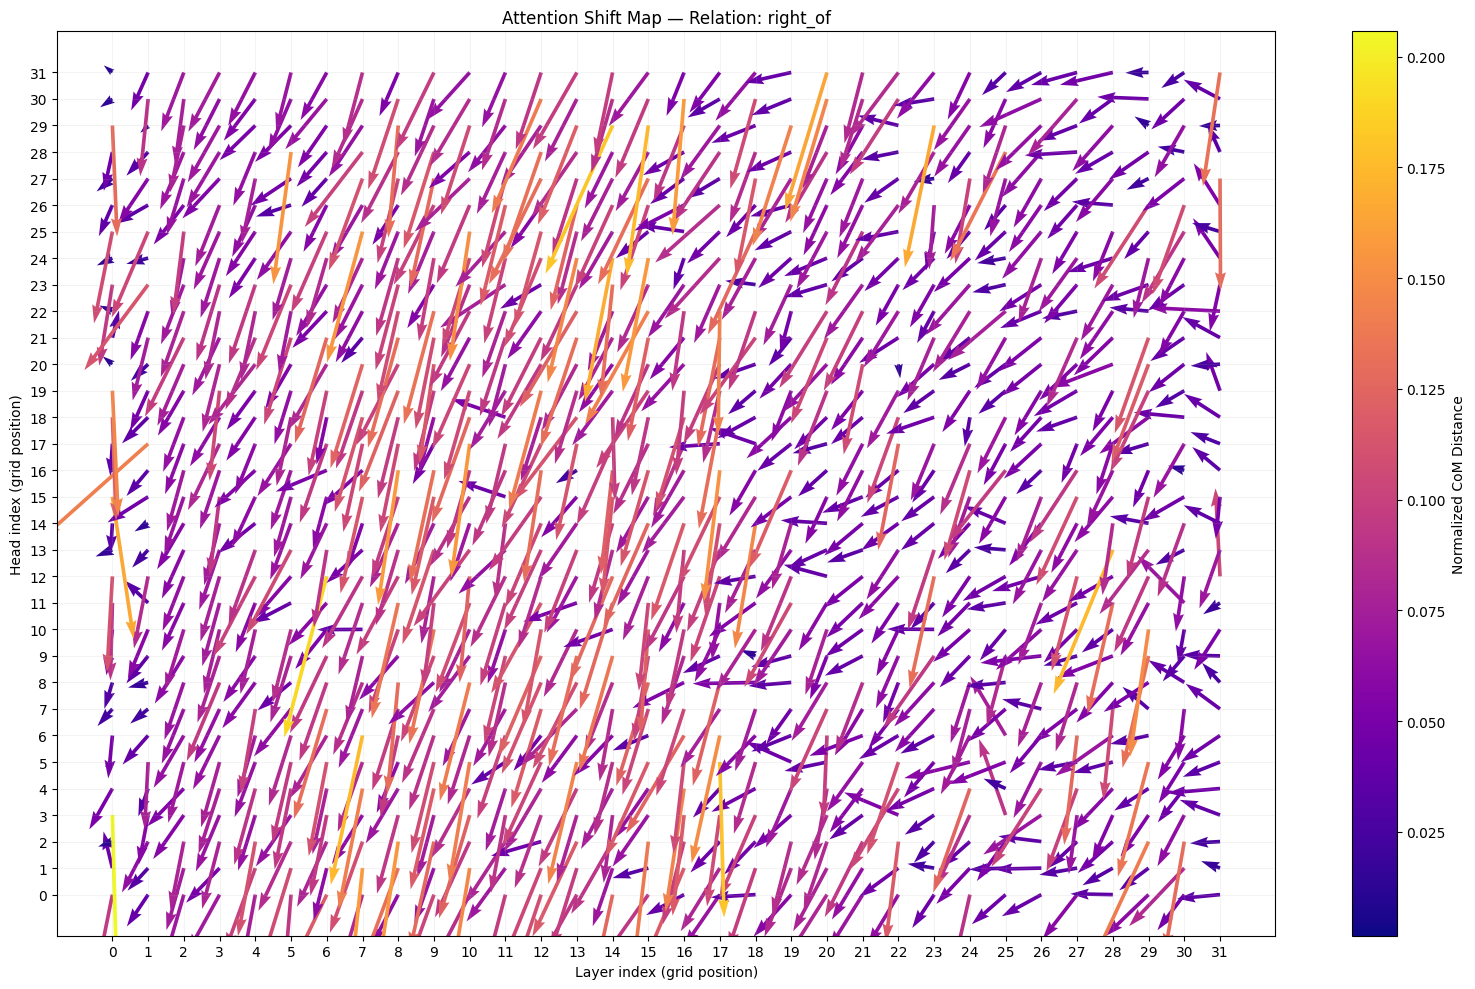

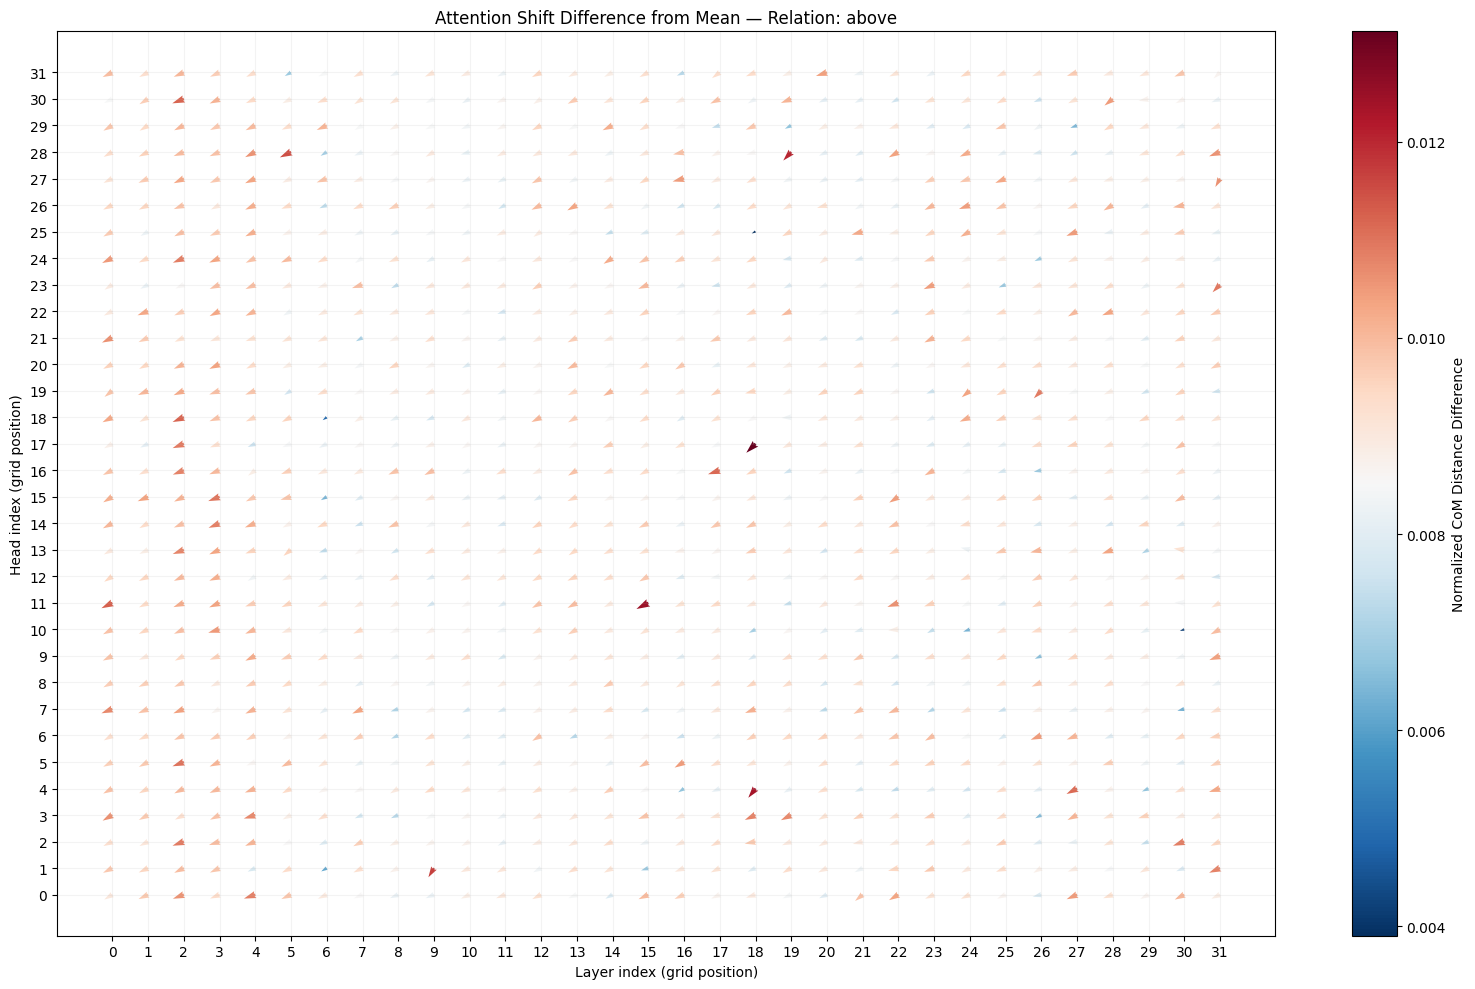

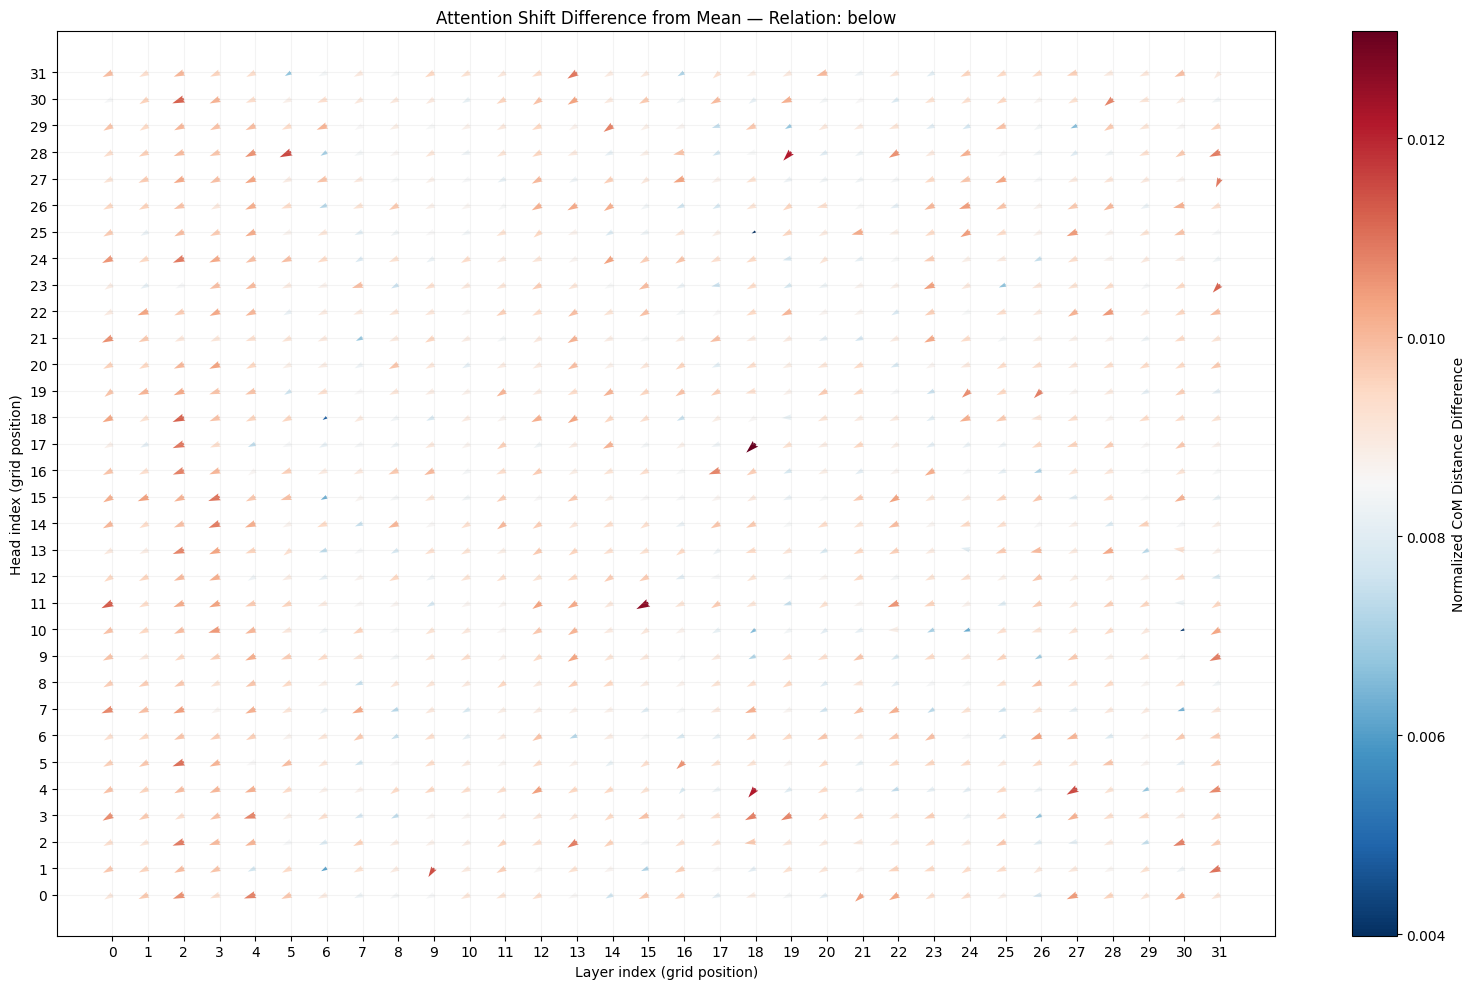

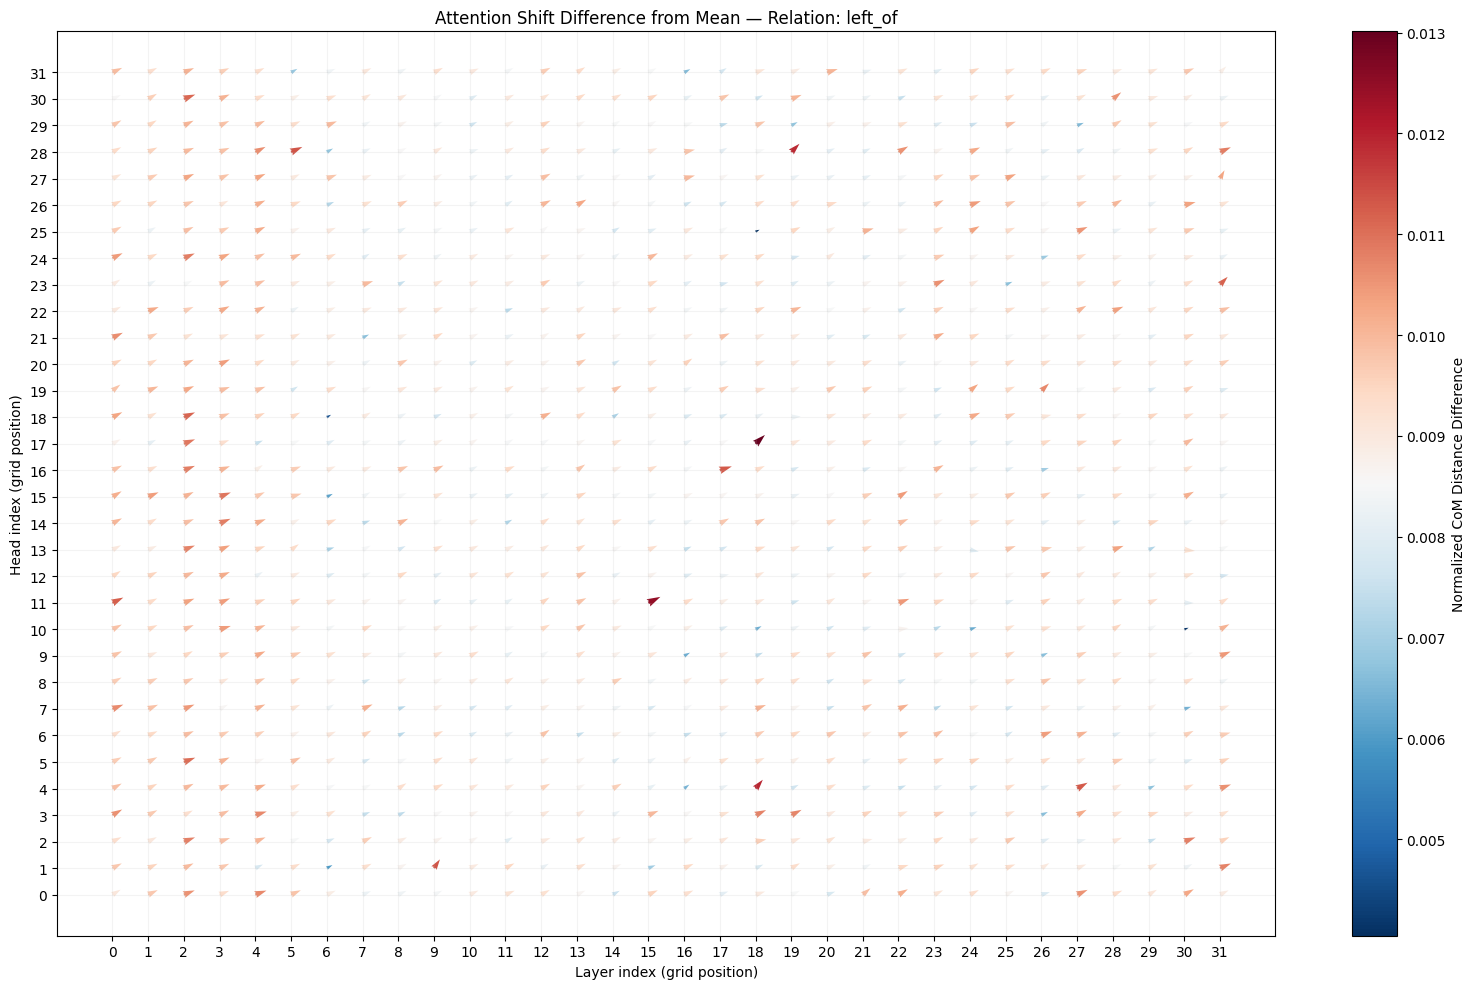

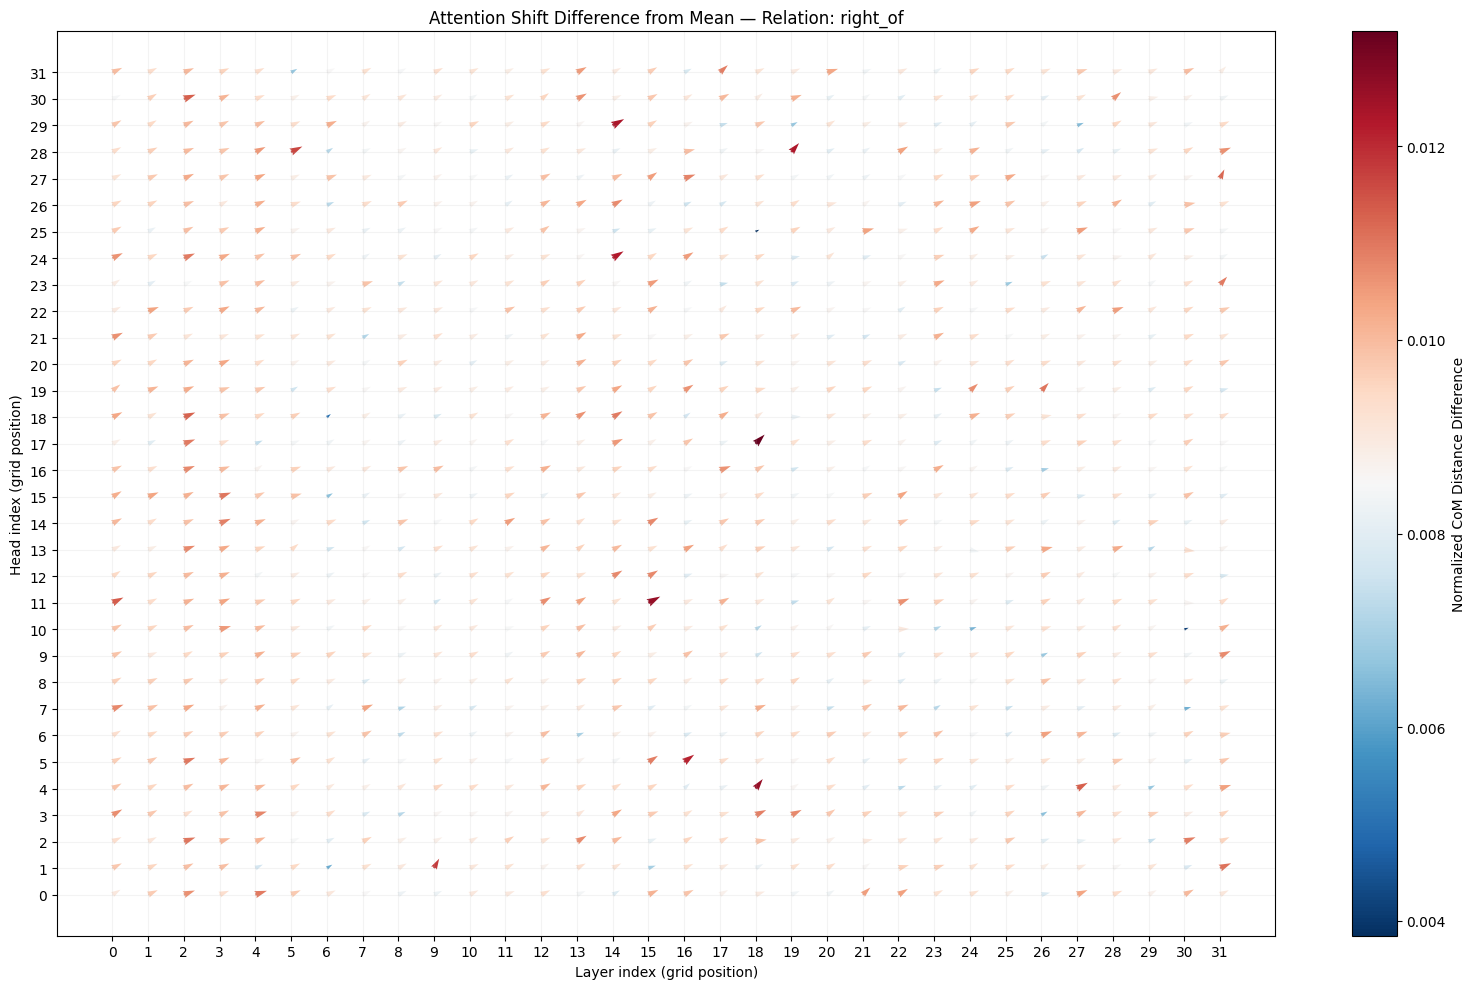

In [40]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# CONFIG
# -------------------------
GRID_SIZE = 24
NUM_LAYERS = 32
NUM_HEADS = 32

SOURCE_GROUP = "last"
TARGET_GROUP = "all_visual"

# Normalize distances by image diagonal, which represents the maximum displacement
MAX_DIST = np.sqrt(2 * (GRID_SIZE - 1) ** 2)
DIST_THRESHOLD = 0.0  # plot everything for now

# -------------------------
# COLLECT VECTORS
# -------------------------
# (relation_type, layer, head) -> list of displacement vectors
vectors = {}

for result in results_com:
    relation_type = result["relation_type"]
    attn_metrics = result["attention_metrics"]
    com_obj = result["com_object"]     
    for pair in attn_metrics["group_pairs"]:
        if (
            pair["source_group"] != SOURCE_GROUP
            or pair["target_group"] != TARGET_GROUP
        ):
            continue

        for layer_idx, layer in enumerate(pair["per_layer"]):
            com_att_list = layer.get("head_com_attentions")  # list of 32 [x,y]
               # single [x,y]
            

            if com_att_list is None or com_obj is None:
                continue

            com_obj = np.asarray(com_obj)

            for head_idx, head_com in enumerate(com_att_list):
                head_com = np.asarray(head_com)
                delta = head_com - com_obj  # computes the vector from object com to the attention com, so direction relative to the object

                key = (relation_type, layer_idx, head_idx)
                vectors.setdefault(key, []).append(delta)
# -------------------------
# AVERAGE VECTORS
# -------------------------
avg_vectors = {}  # (relation, layer, head) -> mean vector

for key, vecs in vectors.items():
    avg_vectors[key] = np.mean(np.stack(vecs), axis=0)

# -------------------------
# COMPUTE OVERALL AVERAGE AND DIFFERENCES
# -------------------------
overall_avg = {}  # (layer, head) -> mean vector across relations

for l in range(NUM_LAYERS):
    for h in range(NUM_HEADS):
        vecs = []
        for relation_type in set(k[0] for k in avg_vectors.keys()):
            key = (relation_type, l, h)
            if key in avg_vectors:
                vecs.append(avg_vectors[key])
        if vecs:
            overall_avg[(l, h)] = np.mean(np.stack(vecs), axis=0)

diff_vectors = {}  # (relation, layer, head) -> diff vector
for key, vec in avg_vectors.items():
    relation_type, l, h = key
    if (l, h) in overall_avg:
        diff_vectors[key] = vec - overall_avg[(l, h)]

print("\nHeads/Layers with significant deviation from mean (normalized):")

significant = []

for (relation_type, l, h), vec in diff_vectors.items():
    norm_dist = np.linalg.norm(vec) / MAX_DIST

    if norm_dist >= DIST_THRESHOLD:
        significant.append((relation_type, l, h, norm_dist))

# Sort by strength (largest deviation first)
significant.sort(key=lambda x: x[3], reverse=True)

for relation_type, l, h, d in significant:
    print(
        f"Relation: {relation_type:>10s} | "
        f"Layer: {l:2d} | Head: {h:2d} | "
        f"ΔCoM distance: {d:.3f}"
    )       

# -------------------------
# VISUALIZE PER RELATION
# -------------------------
for relation_type in sorted(set(k[0] for k in avg_vectors.keys())):

    # Grid
    layers = np.arange(NUM_LAYERS)
    heads = np.arange(NUM_HEADS)
    X, Y = np.meshgrid(layers, heads)

    U = np.zeros((NUM_HEADS, NUM_LAYERS))
    V = np.zeros((NUM_HEADS, NUM_LAYERS))
    M = np.zeros((NUM_HEADS, NUM_LAYERS))  # normalized magnitude

    for l in range(NUM_LAYERS):
        for h in range(NUM_HEADS):
            key = (relation_type, l, h)
            if key not in avg_vectors:
                continue

            vec = avg_vectors[key]

            # Image-space → plot-space
            U[h, l] = vec[0]
            V[h, l] = -vec[1]  # flip Y for image coordinates, because our image coordinates the y axis is positive downwards

            M[h, l] = np.linalg.norm(vec) / MAX_DIST

    # Mask weak vectors
    mask = M < DIST_THRESHOLD
    U = np.ma.masked_where(mask, U)
    V = np.ma.masked_where(mask, V)

    # -------------------------
    # PLOT
    # -------------------------
    plt.figure(figsize=(16, 10))

    Q = plt.quiver(
        X, Y, U, V, M,
        angles="xy",
        scale_units="xy",
        scale=1,
        cmap="plasma",
        pivot="tail",
        width=0.003
    )

    cbar = plt.colorbar(Q)
    cbar.set_label("Normalized CoM Distance")

    plt.xlabel("Layer index (grid position)")
    plt.ylabel("Head index (grid position)")
    plt.title(f"Attention Shift Map — Relation: {relation_type}")

    plt.xticks(np.arange(0, NUM_LAYERS, 1))
    plt.yticks(np.arange(0, NUM_HEADS, 1))
    plt.grid(alpha=0.15)

    plt.tight_layout()
    plt.show()

# -------------------------
# VISUALIZE DIFFERENCES FROM MEAN PER RELATION
# -------------------------
for relation_type in sorted(set(k[0] for k in avg_vectors.keys())):

    # Grid
    layers = np.arange(NUM_LAYERS)
    heads = np.arange(NUM_HEADS)
    X, Y = np.meshgrid(layers, heads)

    U = np.zeros((NUM_HEADS, NUM_LAYERS))
    V = np.zeros((NUM_HEADS, NUM_LAYERS))
    M = np.zeros((NUM_HEADS, NUM_LAYERS))  # normalized magnitude

    for l in range(NUM_LAYERS):
        for h in range(NUM_HEADS):
            key = (relation_type, l, h)
            if key in diff_vectors:
                vec = diff_vectors[key]

                # Image-space → plot-space
                U[h, l] = vec[0]
                V[h, l] = -vec[1]  # flip Y for image coordinates, because our image coordinates the y axis is positive downwards

                M[h, l] = np.linalg.norm(vec) / MAX_DIST

    # Mask weak vectors
    mask = M < DIST_THRESHOLD
    U = np.ma.masked_where(mask, U)
    V = np.ma.masked_where(mask, V)

    # -------------------------
    # PLOT
    # -------------------------
    plt.figure(figsize=(16, 10))

    Q = plt.quiver(
        X, Y, U, V, M,
        angles="xy",
        scale_units="xy",
        scale=1,
        cmap="RdBu_r",  # Diverging colormap for differences
        pivot="tail",
        width=0.003
    )

    cbar = plt.colorbar(Q)
    cbar.set_label("Normalized CoM Distance Difference")

    plt.xlabel("Layer index (grid position)")
    plt.ylabel("Head index (grid position)")
    plt.title(f"Attention Shift Difference from Mean — Relation: {relation_type}")

    plt.xticks(np.arange(0, NUM_LAYERS, 1))
    plt.yticks(np.arange(0, NUM_HEADS, 1))
    plt.grid(alpha=0.15)

    plt.tight_layout()
    plt.show()

Now analyse specific heads of interest

In [41]:
def compute_accuracy_based_on_direction(items, relation_type, print_stats=False):
    """
    This function computes the accuracy for two parts of the image space, given a list of deltas (attention com relative to object com), and their correctness for a given relation_type:
    1) When the attention CoM looks in the right direction relative to the object CoM
    2) When the attention CoM looks in the wrong direction relative to the object CoM

    right direction is when it looks in the direction that matches the relational phrase in the question; otherwise it is the wrong direction

    For example, "is A above B?". Here object is B, and you would expect the model to look above B to answer the question. So right direction is when attention com is placed above the object B, and wrong direction is otherwise
    """

    # Define direction conditions for each relation type
    conditions = {
        "above": lambda delta: delta[1] < 0,  # y_head < y_obj, looking up
        "below": lambda delta: delta[1] > 0,  # y_head > y_obj, looking down
        "left_of": lambda delta: delta[0] < 0,   # x_head < x_obj, looking left
        "right_of": lambda delta: delta[0] > 0,  # x_head > x_obj, looking right
        # Add more if needed
    }

    # Compute accuracies based on direction
    if relation_type in conditions:
        right_corrects = [correct for delta, correct, pred, gt in items if conditions[relation_type](delta)]
        wrong_corrects = [correct for delta, correct, pred, gt in items if not conditions[relation_type](delta)]
        acc_right = np.mean(right_corrects) if right_corrects else 0
        acc_wrong = np.mean(wrong_corrects) if wrong_corrects else 0
        if print_stats:
            print(
                f"[{relation_type}]\n"
                f"Acc (looks in the right dir): {acc_right:6.3f}\n"
                f"Acc (looks in the wrong dir): {acc_wrong:6.3f}\n"
            )
    else:
        if print_stats:
            print(f"No direction condition defined for {relation_type}")
    return acc_right, acc_wrong

[below]
Acc (looks in the right dir):  0.759
Acc (looks in the wrong dir):  0.182



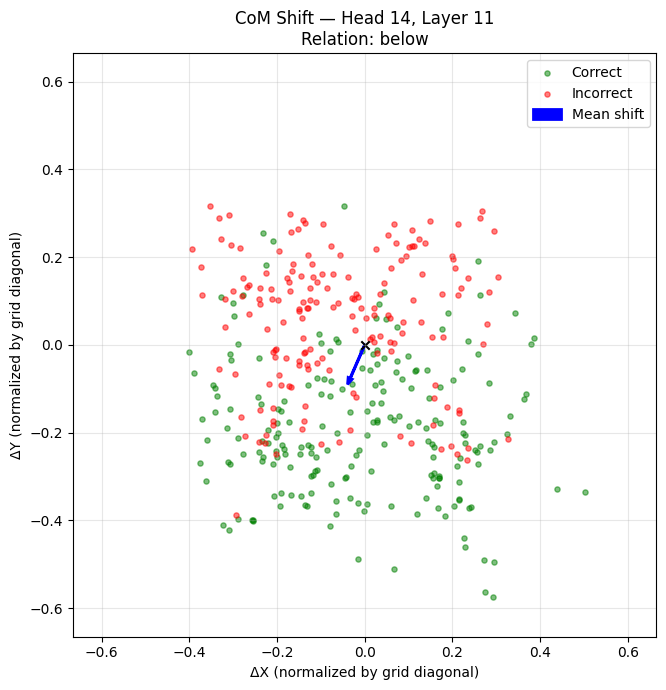

[above]
Acc (looks in the right dir):  0.733
Acc (looks in the wrong dir):  0.048



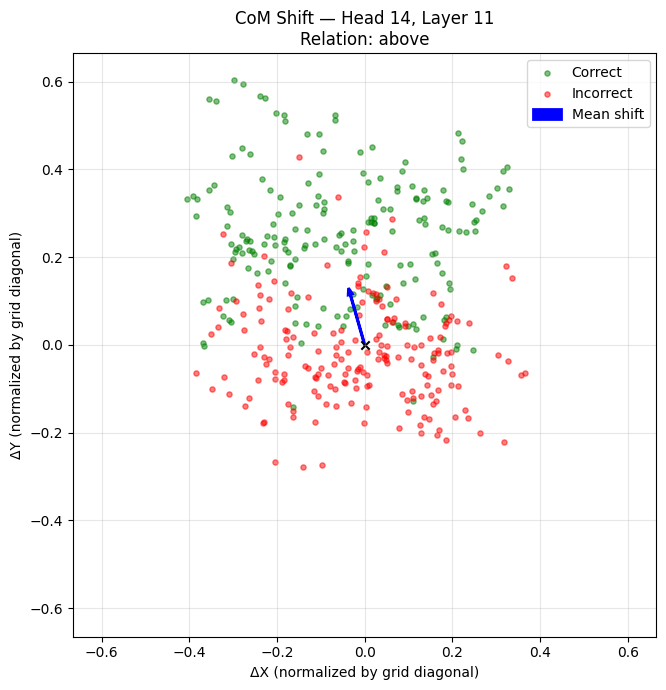

[left_of]
Acc (looks in the right dir):  0.752
Acc (looks in the wrong dir):  0.223



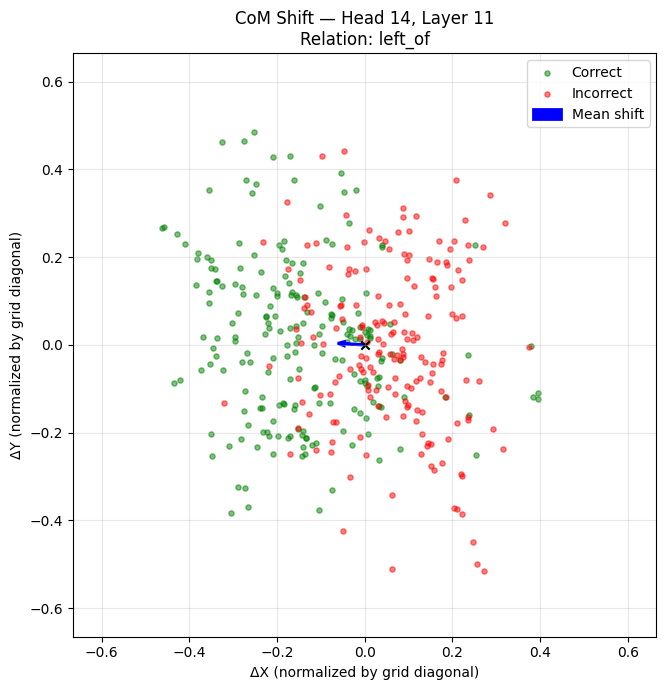

[right_of]
Acc (looks in the right dir):  0.789
Acc (looks in the wrong dir):  0.153



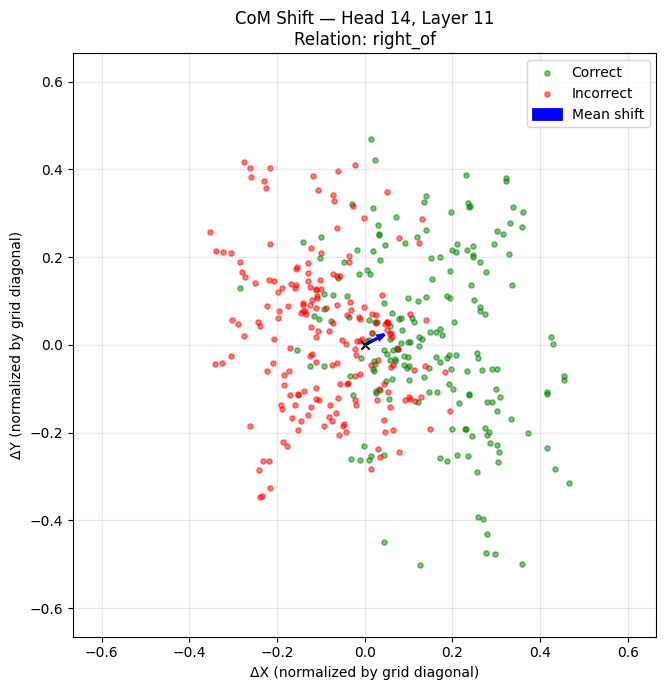

[below]
Acc (looks in the right dir):  0.728
Acc (looks in the wrong dir):  0.167



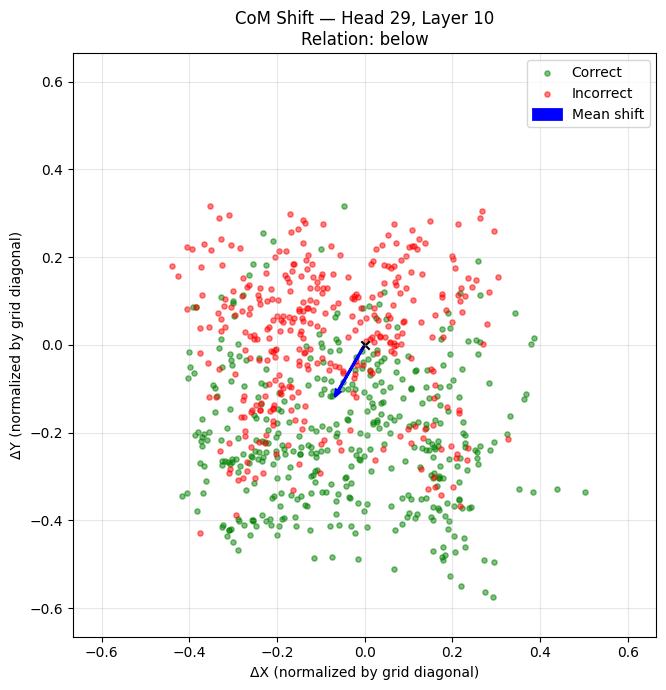

[above]
Acc (looks in the right dir):  0.762
Acc (looks in the wrong dir):  0.123



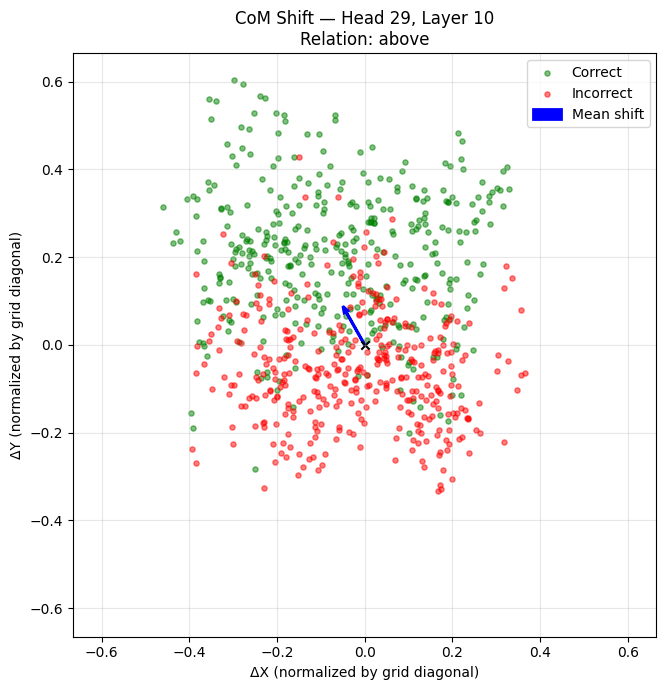

[left_of]
Acc (looks in the right dir):  0.724
Acc (looks in the wrong dir):  0.241



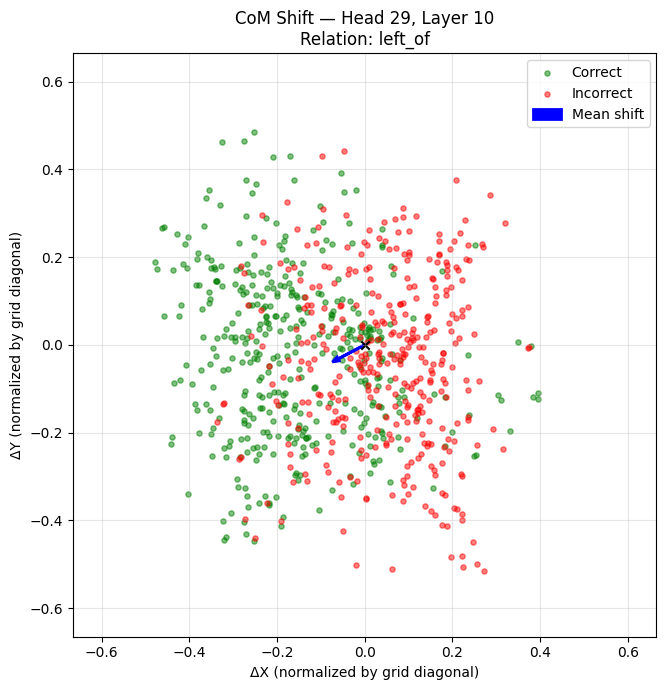

[right_of]
Acc (looks in the right dir):  0.773
Acc (looks in the wrong dir):  0.210



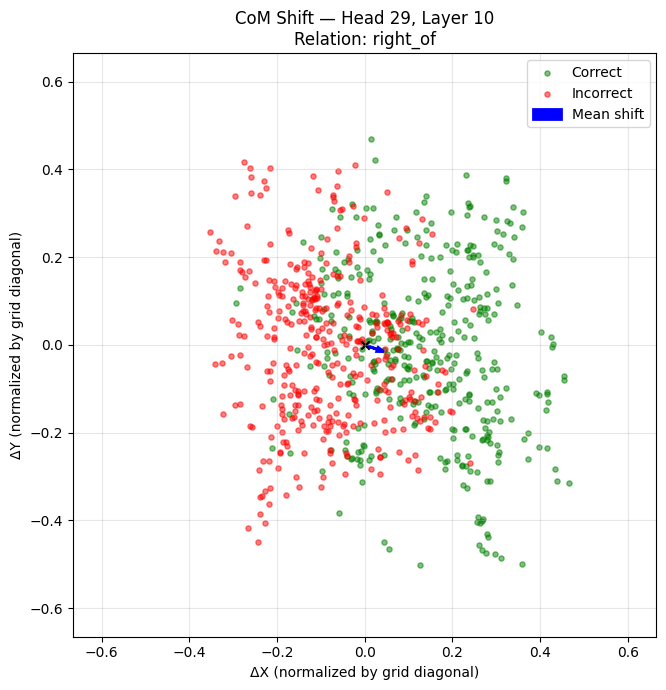

In [42]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# CONFIG (MATCHES YOUR QUANT CODE)
# =========================
GRID_SIZE = 24
MAX_DIST = np.sqrt(2 * (GRID_SIZE - 1) ** 2)


SOURCE_GROUP = "relation"
TARGET_GROUP = "all_visual"

# =========================
# COLLECT NORMALIZED DELTAS
# =========================
deltas_by_relation = {}

interesting_heads = [(11, 14), (10, 29)]
# interesting_heads = [(13, 30)]

for layer, head in interesting_heads:

    SPECIFIC_LAYER = layer
    SPECIFIC_HEAD = head

    for result in results_com:

        relation_type = result["relation_type"]
        attn_metrics = result["attention_metrics"]
        com_obj = result.get("com_object")
        pred = result.get("prediction")
        gt = result.get("ground_truth")
        
        

        if com_obj is None:
            continue

        com_obj = np.asarray(com_obj)

        for pair in attn_metrics["group_pairs"]:
            if (
                pair["source_group"] != SOURCE_GROUP
                or pair["target_group"] != TARGET_GROUP
            ):
                continue

            if SPECIFIC_LAYER >= len(pair["per_layer"]):
                continue

            layer_data = pair["per_layer"][SPECIFIC_LAYER]
            com_att_list = layer_data.get("head_com_attentions")

            if com_att_list is None:
                continue
            if SPECIFIC_HEAD >= len(com_att_list):
                continue

            head_com = com_att_list[SPECIFIC_HEAD]
            if head_com is None:
                continue

            head_com = np.asarray(head_com)

            # Image-space delta
            delta = head_com - com_obj

            # Normalize exactly like your quiver maps
            delta = delta / MAX_DIST

            correct = (pred == gt)

            deltas_by_relation.setdefault(relation_type, []).append((delta, correct, pred, gt))


    # =========================
    # GLOBAL AXIS LIMITS (SHARED)
    # =========================
    all_deltas = np.vstack(
        [np.array([item[0] for item in items]) for items in deltas_by_relation.values() if len(items) > 0]
    )

    max_abs = np.max(np.abs(all_deltas))
    lim = max_abs * 1.1  # padding

    # =========================
    # SCATTER PLOTS (DIRECTION)
    # =========================
    for relation_type, items in deltas_by_relation.items():
        deltas = np.array([item[0] for item in items])
        corrects = np.array([item[1] for item in items])
        preds = np.array([item[2] for item in items])
        gts = np.array([item[3] for item in items])

        compute_accuracy_based_on_direction(items, relation_type, print_stats=True)
        
        correct_deltas = deltas[corrects]
        incorrect_deltas = deltas[~corrects]

        x_correct, y_correct = correct_deltas[:, 0], -correct_deltas[:, 1]
        x_incorrect, y_incorrect = incorrect_deltas[:, 0], -incorrect_deltas[:, 1]

        fig, ax = plt.subplots(figsize=(7, 7))

        ax.scatter(x_correct, y_correct, s=14, alpha=0.5, color='green', label='Correct')
        ax.scatter(x_incorrect, y_incorrect, s=14, alpha=0.5, color='red', label='Incorrect')

        # Mean vector
        mean_delta = np.mean(deltas, axis=0)
        ax.arrow(
            0, 0,
            mean_delta[0], -mean_delta[1],
            head_width=0.01,
            head_length=0.015,
            linewidth=2,
            color="blue",
            label="Mean shift"
        )

        # Origin
        ax.scatter([0], [0], marker="x", color="black")

        ax.set_xlim(-lim, lim)
        ax.set_ylim(-lim, lim)
        ax.set_aspect("equal", adjustable="box")

        ax.set_xlabel("ΔX (normalized by grid diagonal)")
        ax.set_ylabel("ΔY (normalized by grid diagonal)")
        ax.set_title(
            f"CoM Shift — Head {SPECIFIC_HEAD}, Layer {SPECIFIC_LAYER}\nRelation: {relation_type}"
        )

        ax.grid(True, alpha=0.3)
        ax.legend()
        plt.tight_layout()
        plt.show()

        

Now, we compute the separability metric for each head in each layer, and plot a heatmap. This will help us answer the question, "when heads look in the spatially relevant region, do they answer correctly? and what heads shows this pattern?"

______STATS________
Total: 760
TPs: 368
FPs: 336
TNs: 44
FNs: 12


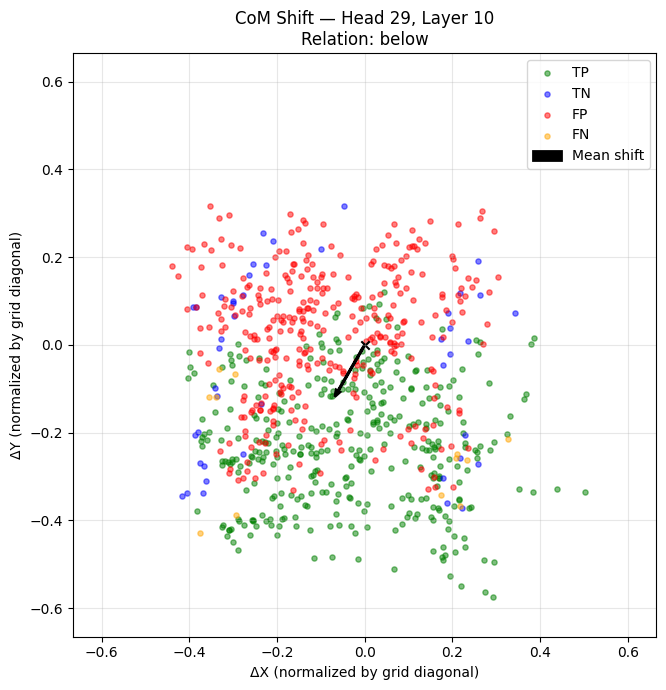

______STATS________
Total: 760
TPs: 376
FPs: 370
TNs: 10
FNs: 4


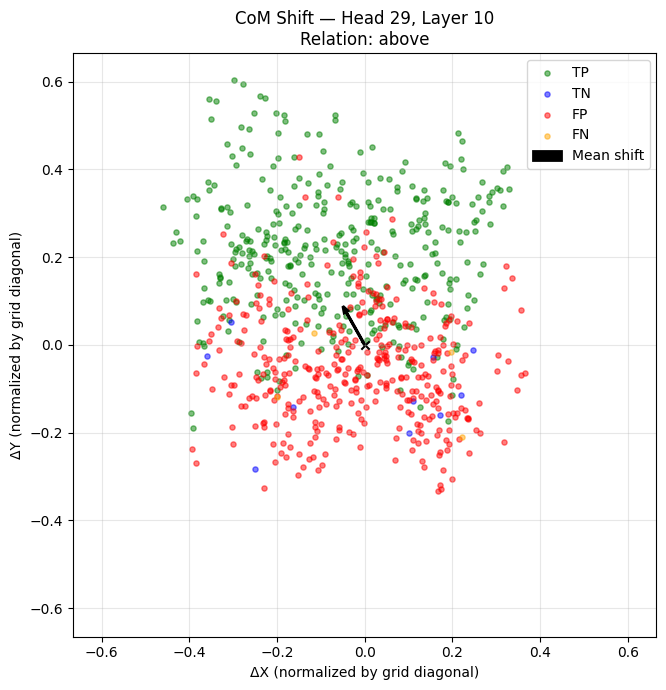

______STATS________
Total: 776
TPs: 378
FPs: 358
TNs: 30
FNs: 10


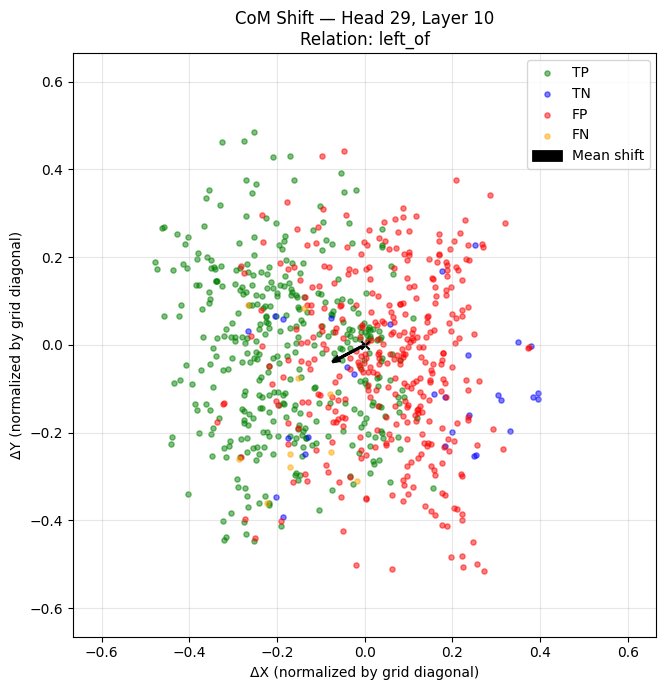

______STATS________
Total: 776
TPs: 386
FPs: 378
TNs: 10
FNs: 2


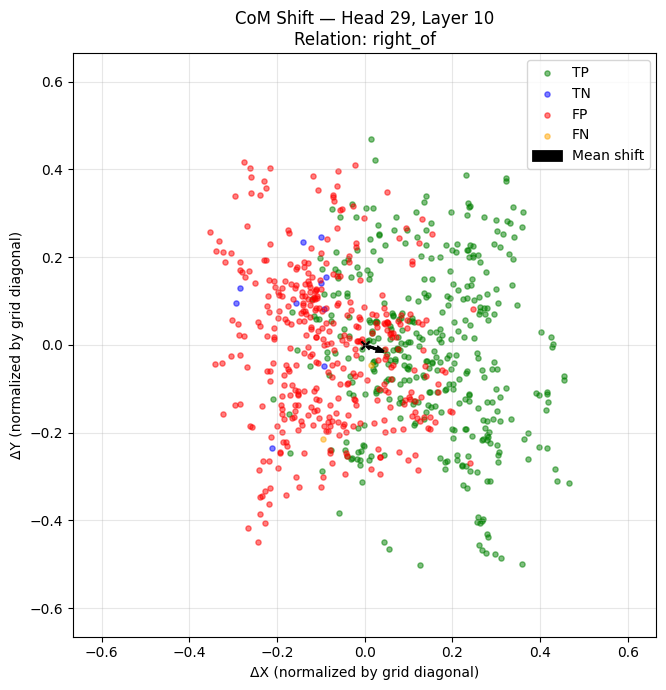

In [ ]:
# =========================
# SCATTER PLOTS (TP, TN, FP, FN)
# =========================

for layer, head in interesting_heads:

    SPECIFIC_LAYER = layer
    SPECIFIC_HEAD = head
    for relation_type, items in deltas_by_relation.items():
        deltas = np.array([item[0] for item in items])
        corrects = np.array([item[1] for item in items])

        # Extract predictions and ground truth for each delta
        preds = np.array([item[2] for item in items]) if len(items[0]) > 2 else np.zeros(len(items))
        gts = np.array([item[3] for item in items]) if len(items[0]) > 3 else np.zeros(len(items))

        # Classify
        TP_mask = (preds == "yes") & (gts == "yes")
        TN_mask = (preds == "no") & (gts == "no")
        FP_mask = (preds == "yes") & (gts == "no")
        FN_mask = (preds == "no") & (gts == "yes")

        print("______STATS________")
        print(f"Total: {len(items)}")
        print(f"TPs: {TP_mask.sum()}")
        print(f"FPs: {FP_mask.sum()}")
        print(f"TNs: {TN_mask.sum()}")
        print(f"FNs: {FN_mask.sum()}")


        x = deltas[:, 0]
        y = -deltas[:, 1]  # flipping y for plotting consistency

        fig, ax = plt.subplots(figsize=(7, 7))

        ax.scatter(x[TP_mask], y[TP_mask], s=14, alpha=0.5, color='green', label='TP')
        ax.scatter(x[TN_mask], y[TN_mask], s=14, alpha=0.5, color='blue', label='TN')
        ax.scatter(x[FP_mask], y[FP_mask], s=14, alpha=0.5, color='red', label='FP')
        ax.scatter(x[FN_mask], y[FN_mask], s=14, alpha=0.5, color='orange', label='FN')

        # Mean vector
        mean_delta = np.mean(deltas, axis=0)
        ax.arrow(
            0, 0,
            mean_delta[0], -mean_delta[1],
            head_width=0.01,
            head_length=0.015,
            linewidth=2,
            color="black",
            label="Mean shift"
        )

        # Origin
        ax.scatter([0], [0], marker="x", color="black")

        ax.set_xlim(-lim, lim)
        ax.set_ylim(-lim, lim)
        ax.set_aspect("equal", adjustable="box")

        ax.set_xlabel("ΔX (normalized by grid diagonal)")
        ax.set_ylabel("ΔY (normalized by grid diagonal)")
        ax.set_title(
            f"CoM Shift — Head {SPECIFIC_HEAD}, Layer {SPECIFIC_LAYER}\nRelation: {relation_type}"
        )

        ax.grid(True, alpha=0.3)
        ax.legend()
        plt.tight_layout()
        plt.show()


Global color scale: ±5.043


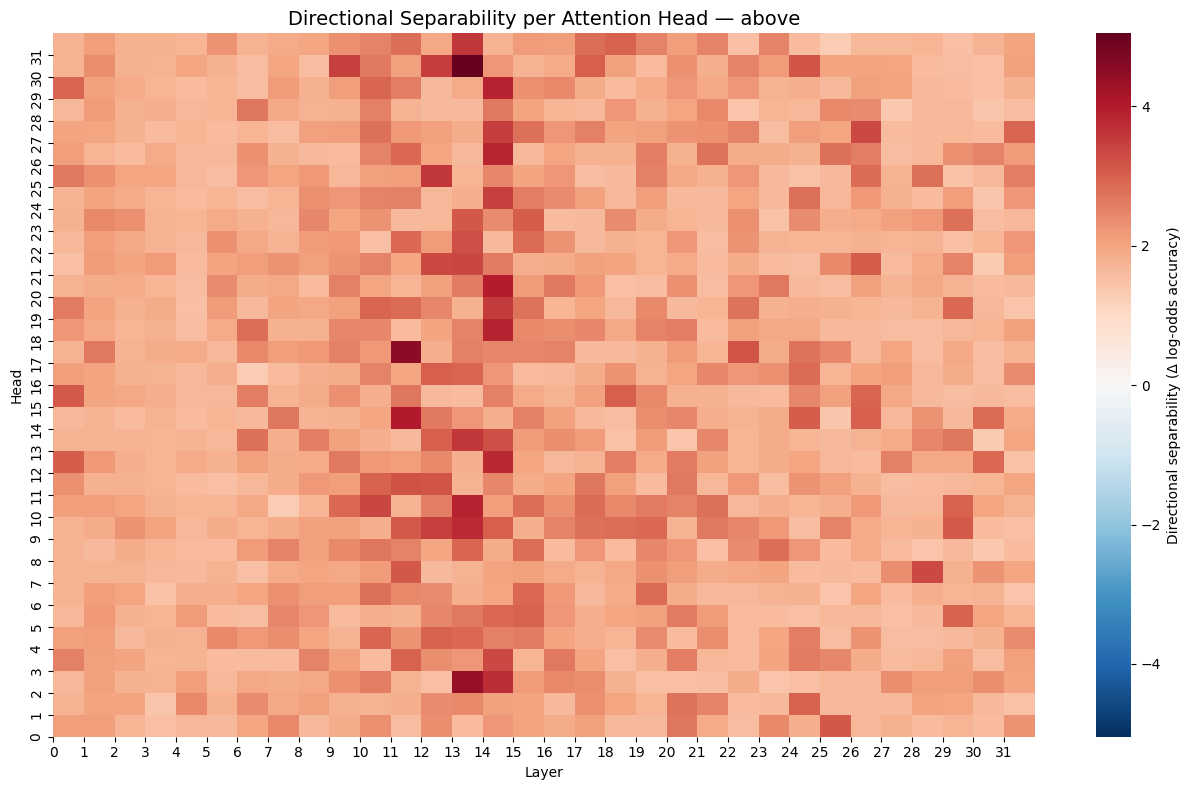

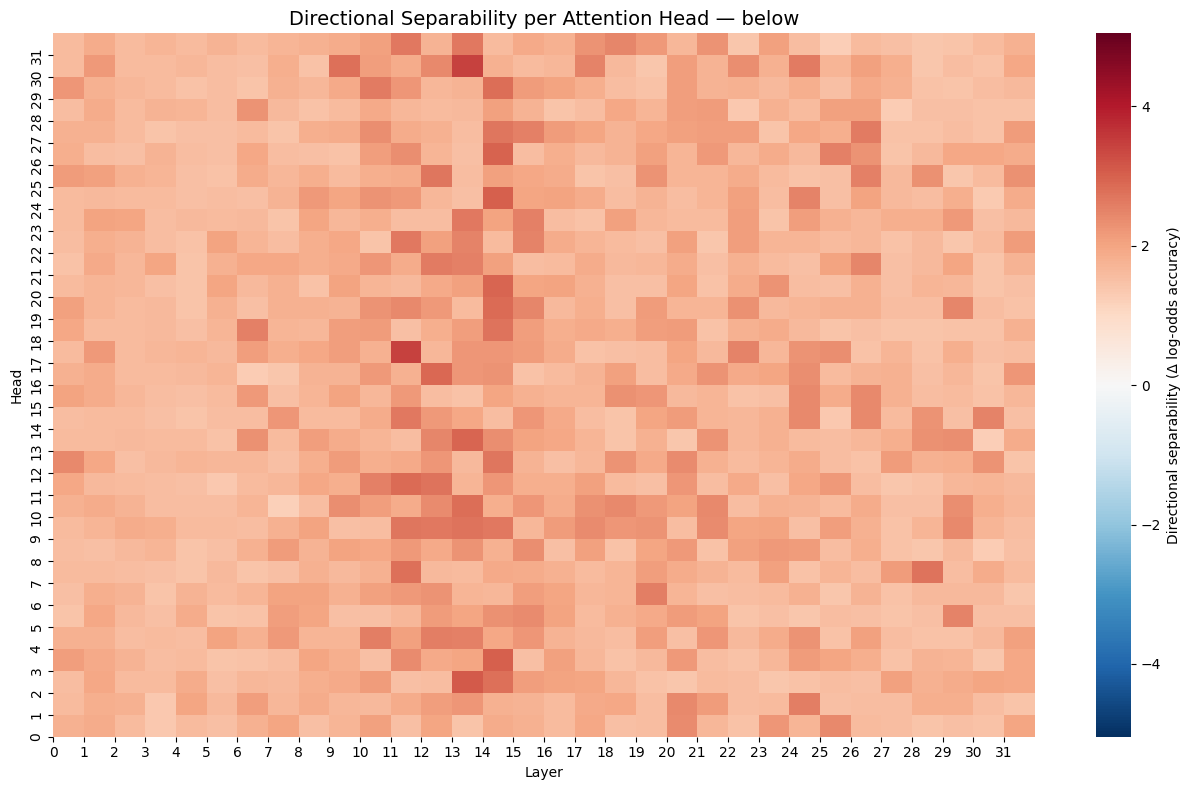

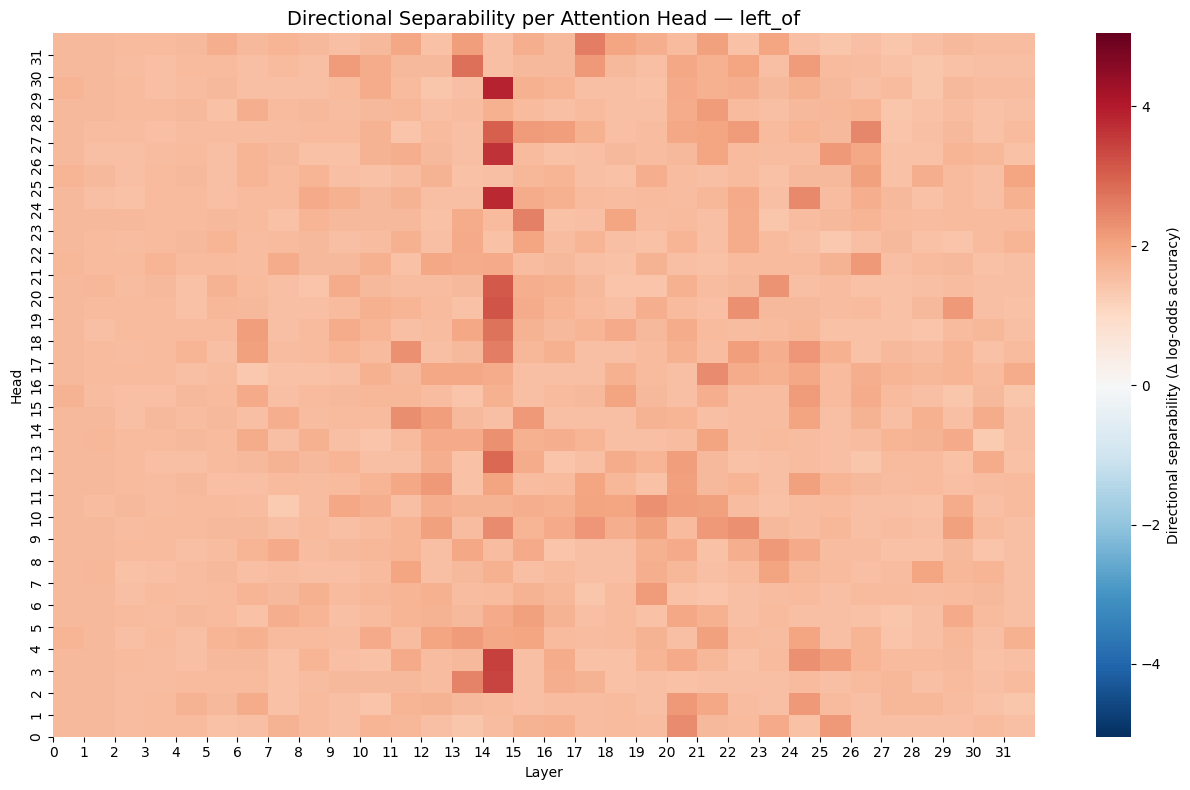

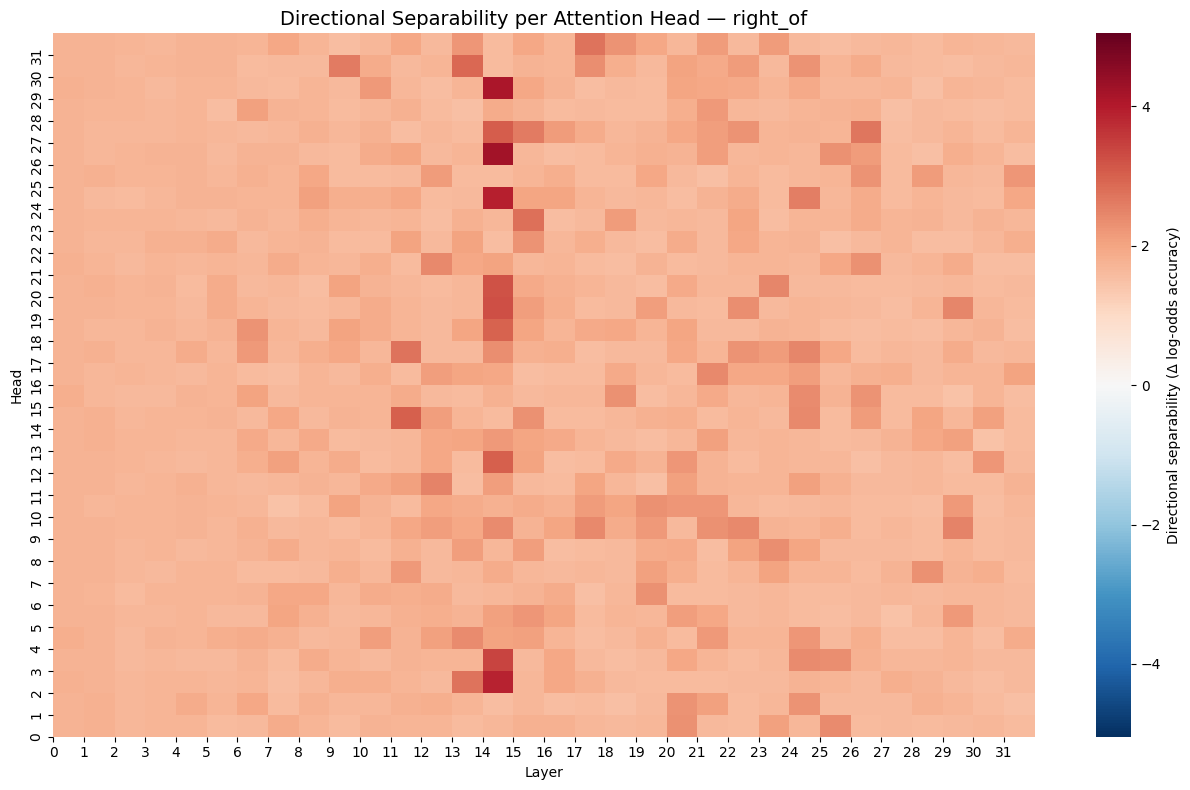

In [16]:
# ==========================================
# Directional Separability Heatmaps per Head
# ==========================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# CONFIG
# =========================
GRID_SIZE = 24
MAX_DIST = np.sqrt(2 * (GRID_SIZE - 1) ** 2)

SOURCE_GROUP = "relation"
TARGET_GROUP = "all_visual"

NUM_LAYERS = 32
NUM_HEADS = 32

MIN_SAMPLES_PER_HEAD = 20   # mask unreliable heads
EPS = 1e-6

# =========================
# COLLECT DELTAS FOR ALL LAYERS AND HEADS
# =========================
# key: (relation_type, layer, head)
# value: list of (delta, correct)
deltas_by_relation_and_head = {}

for result in results_com:
    relation_type = result["relation_type"]
    attn_metrics = result["attention_metrics"]

    com_obj = result.get("com_object")
    pred = result.get("prediction")
    gt = result.get("ground_truth")

    if com_obj is None:
        continue

    com_obj = np.asarray(com_obj)
    correct = (pred == gt)

    for pair in attn_metrics["group_pairs"]:
        if pair["source_group"] != SOURCE_GROUP or pair["target_group"] != TARGET_GROUP:
            continue

        for layer_idx, layer_data in enumerate(pair["per_layer"]):
            com_att_list = layer_data.get("head_com_attentions")
            if com_att_list is None:
                continue

            for head_idx, head_com in enumerate(com_att_list):
                if head_com is None:
                    continue

                head_com = np.asarray(head_com)
                delta = (head_com - com_obj) / MAX_DIST  # normalize

                key = (relation_type, layer_idx, head_idx)
                deltas_by_relation_and_head.setdefault(key, []).append(
                    (delta, correct)
                )

# =========================
# COMPUTE GLOBAL COLOR SCALE
# =========================
all_metrics = []

for (relation_type, layer, head), items in deltas_by_relation_and_head.items():
    if len(items) < MIN_SAMPLES_PER_HEAD:
        continue

    acc_right, acc_wrong = compute_accuracy_based_on_direction(
        items, relation_type, print_stats=False
    )

    metric = (
        np.log((acc_right + EPS) / (1 - acc_right + EPS))
        - np.log((acc_wrong + EPS) / (1 - acc_wrong + EPS))
    )
    all_metrics.append(metric)

vmax = np.nanmax(np.abs(all_metrics))
print(f"Global color scale: ±{vmax:.3f}")

# =========================
# COMPUTE METRICS AND PLOT HEATMAPS
# =========================
relation_types = sorted(set(k[0] for k in deltas_by_relation_and_head.keys()))

for relation_type in relation_types:
    # grid shape: (layers, heads)
    grid = np.full((NUM_LAYERS, NUM_HEADS), np.nan)

    for layer in range(NUM_LAYERS):
        for head in range(NUM_HEADS):
            key = (relation_type, layer, head)
            if key not in deltas_by_relation_and_head:
                continue

            items = deltas_by_relation_and_head[key]
            if len(items) < MIN_SAMPLES_PER_HEAD:
                continue
            
            # print(f"Layer: {layer}; Head: {head}")
            acc_right, acc_wrong = compute_accuracy_based_on_direction(
                items, relation_type, print_stats=False
            )

            metric = (
                np.log((acc_right + EPS) / (1 - acc_right + EPS))
                - np.log((acc_wrong + EPS) / (1 - acc_wrong + EPS))
            )

            grid[layer, head] = metric

    # =========================
    # PLOT
    # =========================
    plt.figure(figsize=(13, 8))

    sns.heatmap(
        grid.T,
        cmap="RdBu_r",
        center=0,
        vmin=-vmax,
        vmax=vmax,
        annot=False,
        cbar_kws={
            "label": "Directional separability (Δ log-odds accuracy)"
        }
    )

    plt.title(
        f"Directional Separability per Attention Head — {relation_type}",
        fontsize=14
    )
    plt.xlabel("Layer")
    plt.ylabel("Head")

    plt.xticks(
        np.arange(0, NUM_LAYERS, 1),
        np.arange(0, NUM_LAYERS, 1)
    )
    plt.yticks(
        np.arange(0, NUM_HEADS, 1),
        np.arange(0, NUM_HEADS, 1)
    )

    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()


In [43]:
# =========================
# LINE PLOT: AVERAGE SEPARABILITY PER LAYER
# =========================

layer_metrics = {layer: [] for layer in range(NUM_LAYERS)}

for (relation_type, layer, head), items in deltas_by_relation_and_head.items():
    if len(items) < MIN_SAMPLES_PER_HEAD:
        continue

    acc_right, acc_wrong = compute_accuracy_based_on_direction(
        items, relation_type, print_stats=False
    )

    metric = (
        np.log((acc_right + EPS) / (1 - acc_right + EPS))
        - np.log((acc_wrong + EPS) / (1 - acc_wrong + EPS))
    )

    layer_metrics[layer].append(metric)

# Compute mean and standard error per layer
layers = np.arange(NUM_LAYERS)
mean_sep = np.array([
    np.nanmean(layer_metrics[l]) if len(layer_metrics[l]) > 0 else np.nan
    for l in layers
])
stderr_sep = np.array([
    np.nanstd(layer_metrics[l]) / np.sqrt(len(layer_metrics[l]))
    if len(layer_metrics[l]) > 1 else np.nan
    for l in layers
])

# =========================
# PLOT
# =========================
plt.figure(figsize=(10, 4))

plt.plot(
    layers,
    mean_sep,
    marker="o",
    linewidth=2,
    label="Mean separability"
)

plt.fill_between(
    layers,
    mean_sep - stderr_sep,
    mean_sep + stderr_sep,
    alpha=0.3,
    label="±1 SE"
)

plt.axhline(0, linestyle="--", linewidth=1)

plt.xlabel("Layer")
plt.ylabel("Directional separability (Δ log-odds)")
plt.title("Average Directional Separability Across Layers")
plt.xticks(layers)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


ValueError: not enough values to unpack (expected 4, got 2)